# Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
pd.set_option('display.max_column', None)

In [4]:
data = pd.read_csv('data/high_diamond_ranked_10min.csv')
df_EDA = data.copy()
df_EDA

,gameId,blueWins,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons,blueHeralds,blueTowersDestroyed,blueTotalGold,blueAvgLevel,blueTotalExperience,blueTotalMinionsKilled,blueTotalJungleMinionsKilled,blueGoldDiff,blueExperienceDiff,blueCSPerMin,blueGoldPerMin,redWardsPlaced,redWardsDestroyed,redFirstBlood,redKills,redDeaths,redAssists,redEliteMonsters,redDragons,redHeralds,redTowersDestroyed,redTotalGold,redAvgLevel,redTotalExperience,redTotalMinionsKilled,redTotalJungleMinionsKilled,redGoldDiff,redExperienceDiff,redCSPerMin,redGoldPerMin
0,4519157822,0,28,2,1,9,6,11,0,0,0,0,17210,6.6,17039,195,36,643,-8,19.5,1721.0,15,6,0,6,9,8,0,0,0,0,16567,6.8,17047,197,55,-643,8,19.7,1656.7
1,4523371949,0,12,1,0,5,5,5,0,0,0,0,14712,6.6,16265,174,43,-2908,-1173,17.4,1471.2,12,1,1,5,5,2,2,1,1,1,17620,6.8,17438,240,52,2908,1173,24.0,1762.0
2,4521474530,0,15,0,0,7,11,4,1,1,0,0,16113,6.4,16221,186,46,-1172,-1033,18.6,1611.3,15,3,1,11,7,14,0,0,0,0,17285,6.8,17254,203,28,1172,1033,20.3,1728.5
3,4524384067,0,43,1,0,4,5,5,1,0,1,0,15157,7.0,17954,201,55,-1321,-7,20.1,1515.7,15,2,1,5,4,10,0,0,0,0,16478,7.0,17961,235,47,1321,7,23.5,1647.8
4,4436033771,0,75,4,0,6,6,6,0,0,0,0,16400,7.0,18543,210,57,-1004,230,21.0,1640.0,17,2,1,6,6,7,1,1,0,0,17404,7.0,18313,225,67,1004,-230,22.5,1740.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9874,4527873286,1,17,2,1,7,4,5,1,1,0,0,17765,7.2,18967,211,69,2519,2469,21.1,1776.5,46,3,0,4,7,7,0,0,0,0,15246,6.8,16498,229,34,-2519,-2469,22.9,1524.6
9875,4527797466,1,54,0,0,6,4,8,1,1,0,0,16238,7.2,19255,233,48,782,888,23.3,1623.8,12,21,1,4,6,3,0,0,0,0,15456,7.0,18367,206,56,-782,-888,20.6,1545.6
9876,4527713716,0,23,1,0,6,7,5,0,0,0,0,15903,7.0,18032,210,45,-2416,-1877,21.0,1590.3,14,0,1,7,6,11,1,1,0,0,18319,7.4,19909,261,60,2416,1877,26.1,1831.9
9877,4527628313,0,14,4,1,2,3,3,1,1,0,0,14459,6.6,17229,224,48,-839,-1085,22.4,1445.9,66,4,0,3,2,1,0,0,0,0,15298,7.2,18314,247,40,839,1085,24.7,1529.8


Here I gather notes about the dataset and following my analysis framework.

# EDA

## Notes

Here I gather notes about the dataset and following my analysis framework.

### <u>1st basic analysis</u>
##### Form analysis :
- **<u>Target variable</u>** : blueWins
- **<u>Shape</u>** : (9879, 40)
- **<u>Variable dtypes</u>** : 40 quantitatives, with 34 int and 6 float, already encoded
- **<u>Missing values analysis</u>** : clean dataset, not a single NaN value
- **<u>Removing useless columns</u>** : removing the `gameID`, which we won't use in this model, and the `CSPerMin` columns, since it's basically equivalent to `TotalMinionsKilled`columns


##### 'Substance' analysis :
- **<u>Target visualization</u>** : Almost perfect 50/50, slightly in favor of 0 (loss) 
     
- **<u>Variables descriptions</u>** : 
    * Continuous variables : mostly normal distribution (slightly skewed sometimes), but not standard normal distribution --> also `blueAvgLevel` and `redAvgLevel` are not continuous but discrete, with dtype=float
    * Qualitative variables : no categorical variable in this dataset, already encoded

- **<u>Target / Variables relationship</u>** : Some variables seem to greatly impact our target variable : GoldDiff, ExperienceDiff, FirstBlood, Towers Destroyed or Elite Monsters, which can lead to significant results:
    * having first blood or the first herald gives you almost a 60% win rate
    * having for instance 2 towers to 0 at 10mn gives you at least 80% win rate on average ; even more than having 2 Elite Monsters to 0 (meaning Herald + Drake) at 10mn.


##### Initial conclusion :
* Several variables important when it comes to winning, but some of them are directly correlated to others (GoldDiff is a combination of a few of them)
* No missing values
* Mostly normal distributions in continuous variables
    
    
### <u>More detailed analysis</u>

- **<u>Variables / Variables relationship</u>** :
    * Many variables are strongly correlated or strongly inversely correlated

- **<u>NaN analysis</u>** : 
    * no NaN value in the dataset
    

## Code for EDA

### Form Analysis

In [5]:
df_EDA.shape

(9879, 40)

In [6]:
df_EDA.dtypes.value_counts()

int64      34
float64     6
Name: count, dtype: int64

Let's check the missing values for the entire dataset using sns.heatmap 

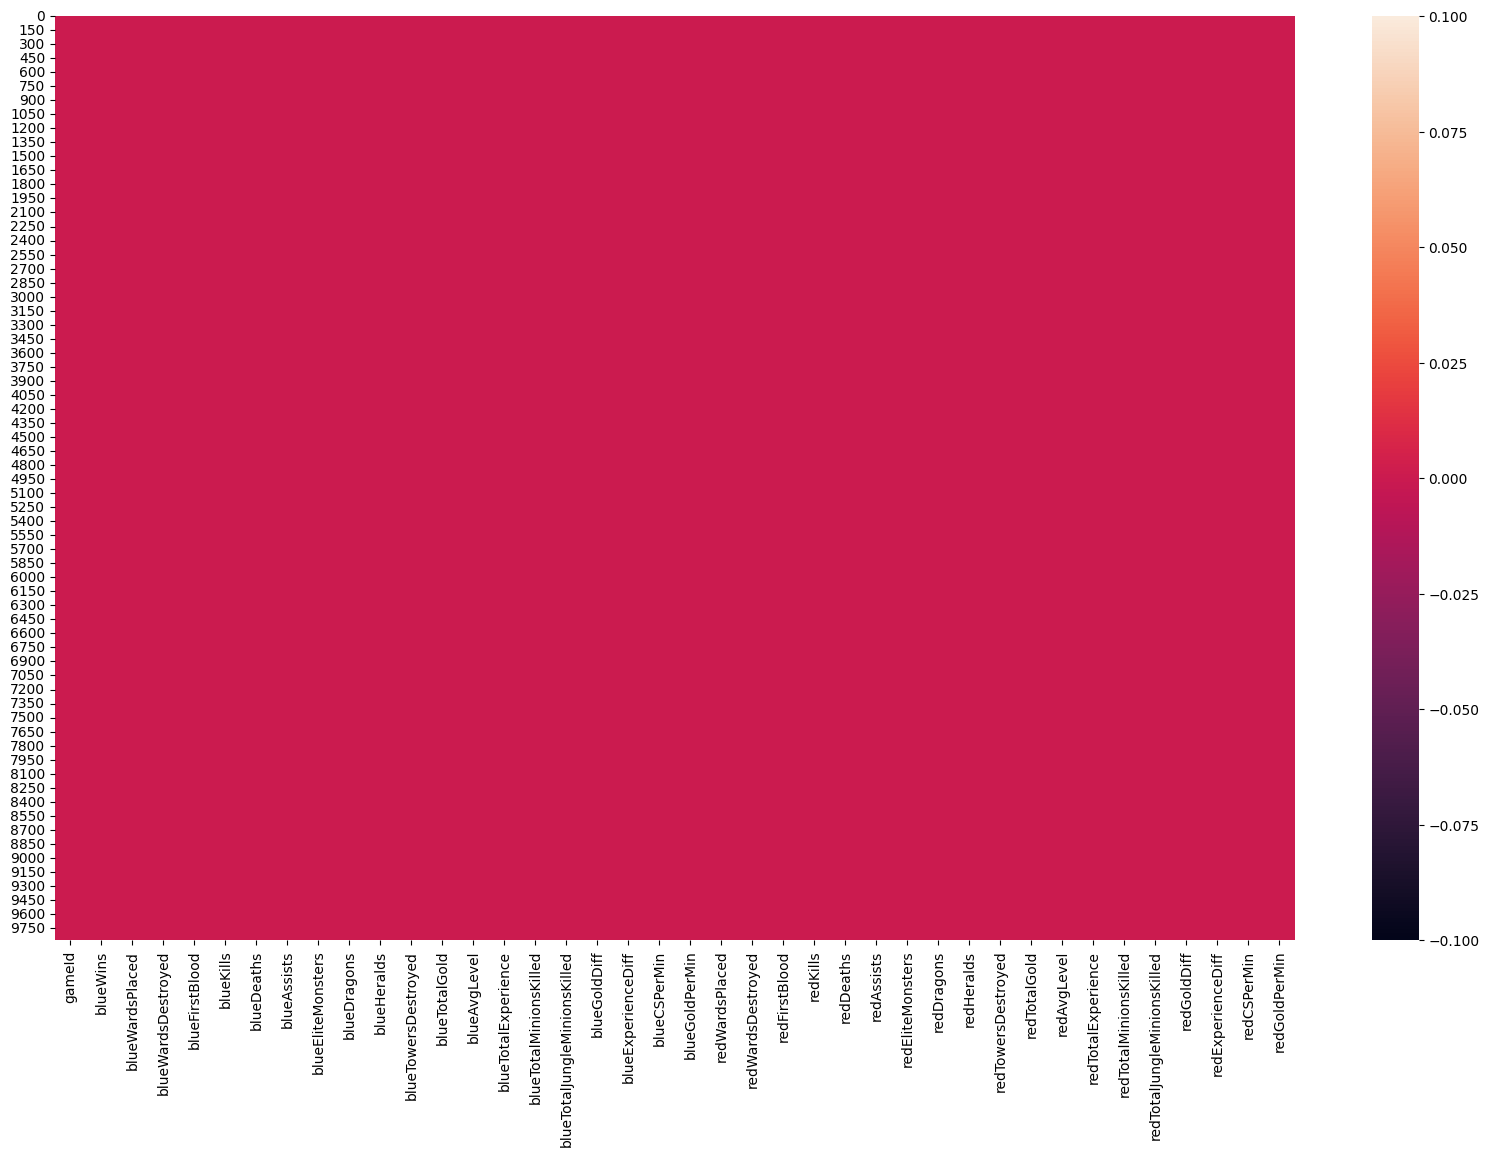

In [7]:
plt.figure(figsize=(20,12))
sns.heatmap(df_EDA.isna());

### 'Substance' Analysis

In [8]:
df_EDA['blueWins'].value_counts(normalize=True)

blueWins
0    0.500962
1    0.499038
Name: proportion, dtype: float64

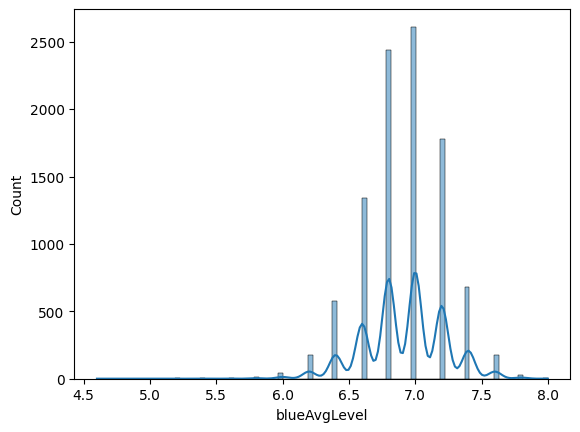

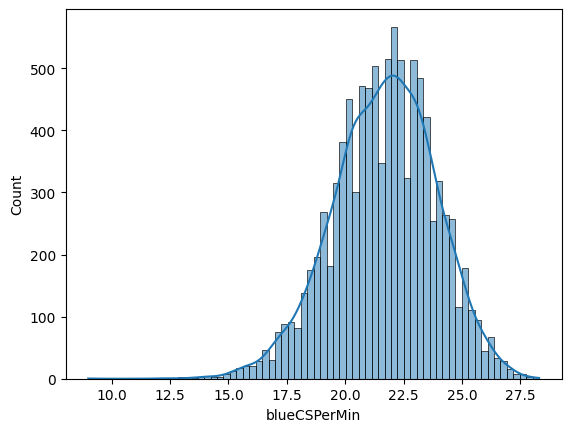

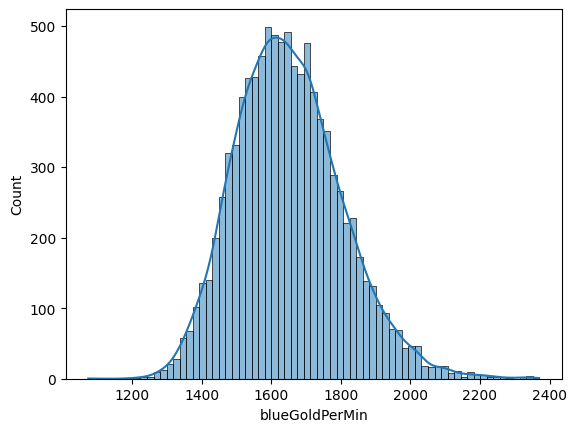

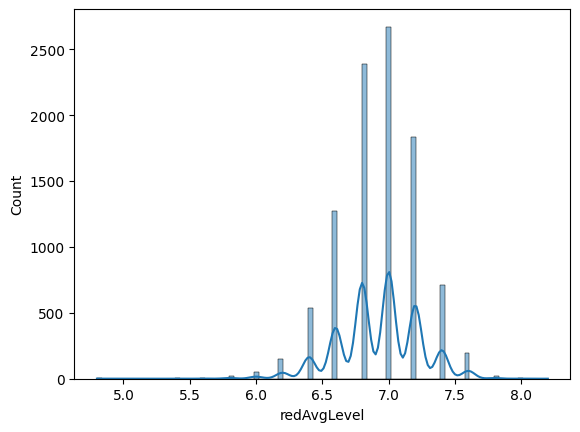

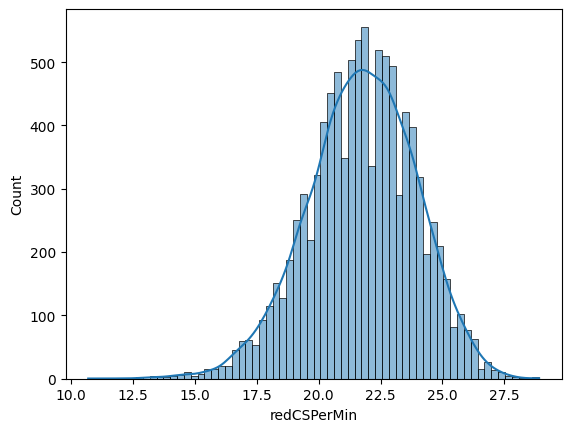

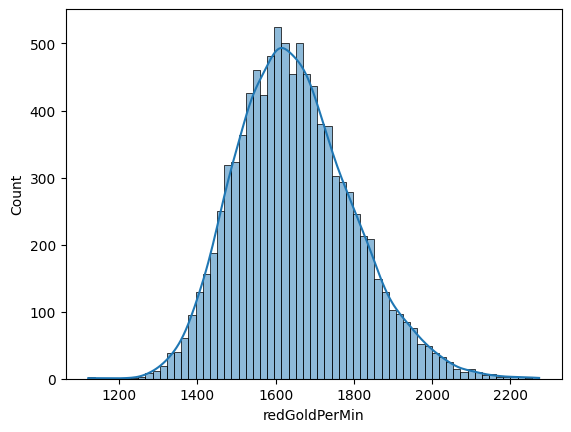

In [9]:
# Histograms for continuous variables (not all are continuous but dtype=float)

for col in df_EDA.select_dtypes('float').columns:
    plt.figure()
    sns.histplot(df_EDA[col], kde=True);

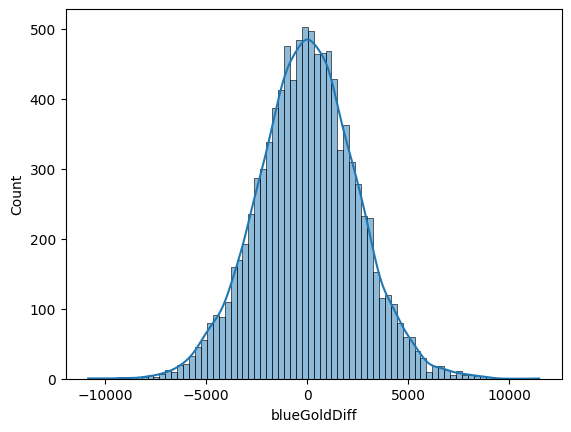

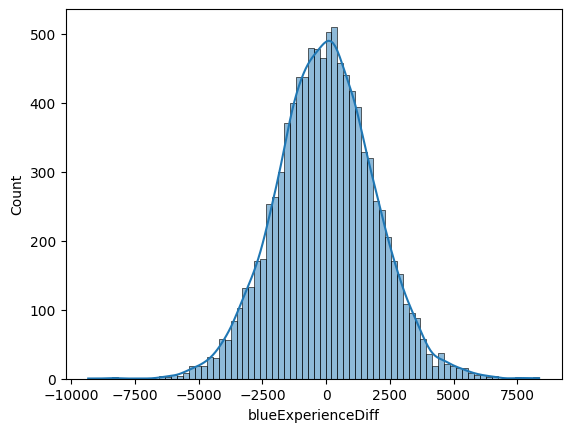

In [10]:
for col in ['blueGoldDiff', 'blueExperienceDiff']:
    plt.figure()
    sns.histplot(df_EDA[col], kde=True);

Let's create 4 sub-datasets according to the target: 
- Blue won (1)
- Blue lost (0)
- Blue dataset
- Red dataset

In [11]:
win_df_EDA = df_EDA[df_EDA['blueWins'] == 1]
loss_df_EDA = df_EDA[df_EDA['blueWins'] == 0]

print(loss_df_EDA.shape)
loss_df_EDA.sample(5)

(4949, 40)


,gameId,blueWins,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons,blueHeralds,blueTowersDestroyed,blueTotalGold,blueAvgLevel,blueTotalExperience,blueTotalMinionsKilled,blueTotalJungleMinionsKilled,blueGoldDiff,blueExperienceDiff,blueCSPerMin,blueGoldPerMin,redWardsPlaced,redWardsDestroyed,redFirstBlood,redKills,redDeaths,redAssists,redEliteMonsters,redDragons,redHeralds,redTowersDestroyed,redTotalGold,redAvgLevel,redTotalExperience,redTotalMinionsKilled,redTotalJungleMinionsKilled,redGoldDiff,redExperienceDiff,redCSPerMin,redGoldPerMin
4344,4500650669,0,16,3,0,5,6,3,0,0,0,0,16032,7.0,18159,229,58,-478,-389,22.9,1603.2,23,3,1,6,5,6,1,1,0,0,16510,7.0,18548,221,48,478,389,22.1,1651.0
2634,4501802834,0,10,2,0,1,6,1,0,0,0,0,14012,6.8,17304,230,45,-2670,-1395,23.0,1401.2,17,0,1,6,1,6,1,1,0,0,16682,7.0,18699,218,59,2670,1395,21.8,1668.2
1196,4509495092,0,17,1,0,1,5,0,1,1,0,0,14004,6.4,16302,217,39,-1113,-1381,21.7,1400.4,10,2,1,5,1,5,0,0,0,0,15117,7.0,17683,212,32,1113,1381,21.2,1511.7
1073,4505075524,0,10,0,0,5,8,2,0,0,0,0,15913,6.8,18220,225,46,-1091,-892,22.5,1591.3,16,1,1,8,5,6,1,1,0,0,17004,7.2,19112,208,66,1091,892,20.8,1700.4
8828,4525943268,0,17,3,0,7,10,4,0,0,0,0,15970,6.8,17608,196,55,-2046,-691,19.6,1597.0,15,2,1,10,7,10,0,0,0,0,18016,7.0,18299,226,40,2046,691,22.6,1801.6


In [12]:
blue_df = df_EDA[[col for col in df_EDA.columns if 'blue' in col]]
red_df = df_EDA[[col for col in df_EDA.columns if 'red' in col]]
blue_df

,blueWins,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons,blueHeralds,blueTowersDestroyed,blueTotalGold,blueAvgLevel,blueTotalExperience,blueTotalMinionsKilled,blueTotalJungleMinionsKilled,blueGoldDiff,blueExperienceDiff,blueCSPerMin,blueGoldPerMin
0,0,28,2,1,9,6,11,0,0,0,0,17210,6.6,17039,195,36,643,-8,19.5,1721.0
1,0,12,1,0,5,5,5,0,0,0,0,14712,6.6,16265,174,43,-2908,-1173,17.4,1471.2
2,0,15,0,0,7,11,4,1,1,0,0,16113,6.4,16221,186,46,-1172,-1033,18.6,1611.3
3,0,43,1,0,4,5,5,1,0,1,0,15157,7.0,17954,201,55,-1321,-7,20.1,1515.7
4,0,75,4,0,6,6,6,0,0,0,0,16400,7.0,18543,210,57,-1004,230,21.0,1640.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9874,1,17,2,1,7,4,5,1,1,0,0,17765,7.2,18967,211,69,2519,2469,21.1,1776.5
9875,1,54,0,0,6,4,8,1,1,0,0,16238,7.2,19255,233,48,782,888,23.3,1623.8
9876,0,23,1,0,6,7,5,0,0,0,0,15903,7.0,18032,210,45,-2416,-1877,21.0,1590.3
9877,0,14,4,1,2,3,3,1,1,0,0,14459,6.6,17229,224,48,-839,-1085,22.4,1445.9


### Target / Most important variables relationship

As a high-elo LoL player of myself (GrandMaster), I assume some variables are of greater importances than others --> let's check if that is the case, by plotting relationships between the Target and some variables of interest (distributions)

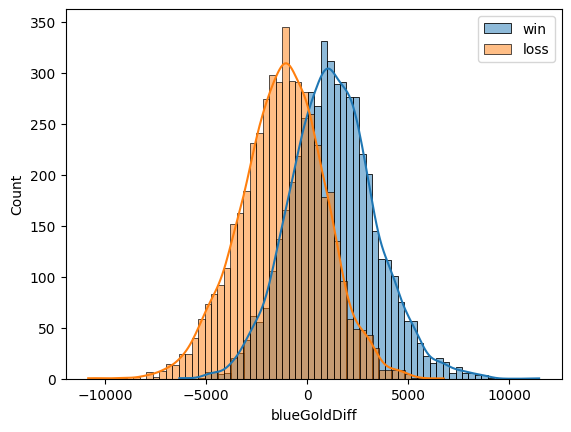

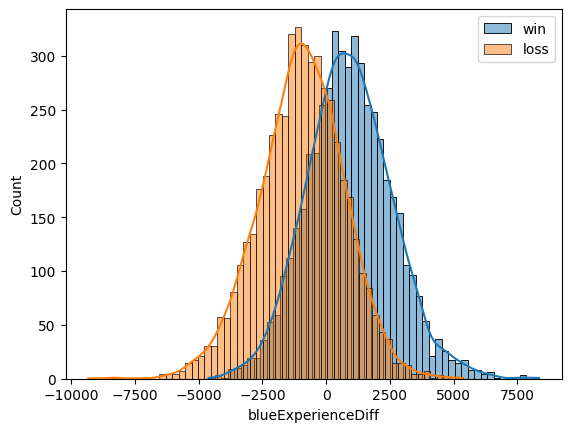

In [13]:
for col in ['blueGoldDiff', 'blueExperienceDiff']:
    plt.figure()
    sns.histplot(win_df_EDA[col], kde=True, label='win')
    sns.histplot(loss_df_EDA[col], kde=True, label='loss')
    plt.legend();

We can see great differences in distribution in win vs loss for these 2 variables GoldDiff and ExperienceDiff, which makes sense --> GoldDiff derives from combination of more kills, more objectives like Elite Monsters killed, Towers destroyed, or number of Minions Killed

Text(0, 0.5, 'Proportion')

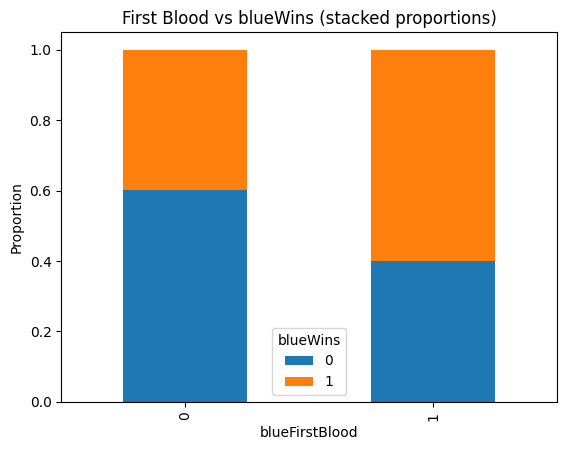

In [14]:
crosstab_fb = pd.crosstab(df_EDA['blueFirstBlood'], df_EDA['blueWins'], normalize='index')
crosstab_fb.plot(kind='bar', stacked=True)
plt.title(f'First Blood vs blueWins (stacked proportions)')
plt.ylabel('Proportion')

We now plot heatmaps for interactions and combined effects (when Red and Blue have non-exclusive values) : 
- for Elite Monsters (and within Monsters decomposition of Dragons and Heralds to check which one seems more important at first)
- for Towers Destroyed

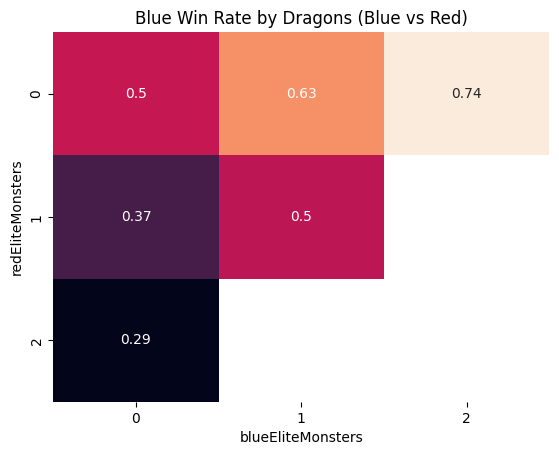

In [15]:
crosstab_monsters = pd.crosstab(df_EDA['redEliteMonsters'], df_EDA['blueEliteMonsters'], values=df_EDA['blueWins'], aggfunc='mean')
sns.heatmap(crosstab_monsters, annot=True, cbar=False)
plt.title('Blue Win Rate by Dragons (Blue vs Red)')
plt.show();

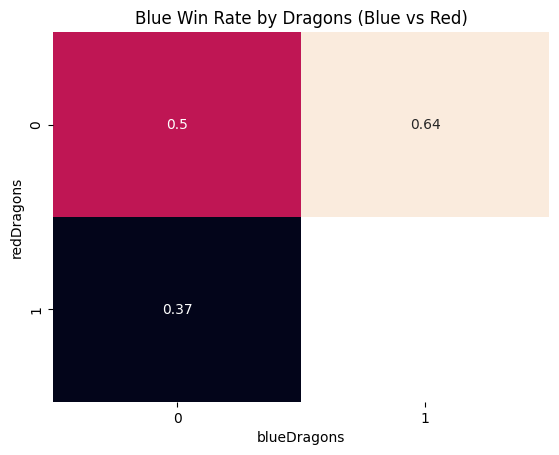

In [16]:
crosstab_dragons = pd.crosstab(df_EDA['redDragons'], df_EDA['blueDragons'], values=df_EDA['blueWins'], aggfunc='mean')
sns.heatmap(crosstab_dragons, annot=True, cbar=False)
plt.title('Blue Win Rate by Dragons (Blue vs Red)')
plt.show();

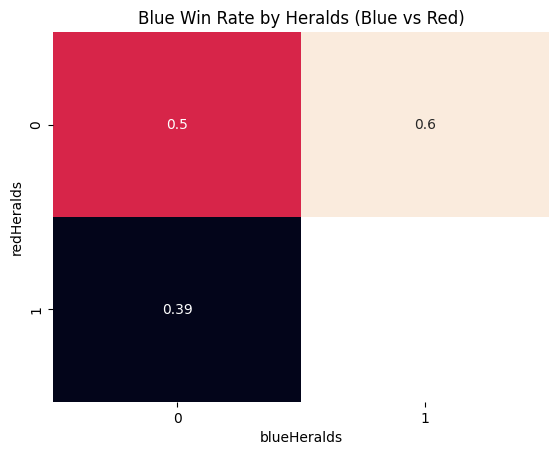

In [17]:
crosstab_heralds = pd.crosstab(df_EDA['redHeralds'], df_EDA['blueHeralds'], values=df_EDA['blueWins'], aggfunc='mean')
sns.heatmap(crosstab_heralds, annot=True, cbar=False)
plt.title('Blue Win Rate by Heralds (Blue vs Red)')
plt.show();

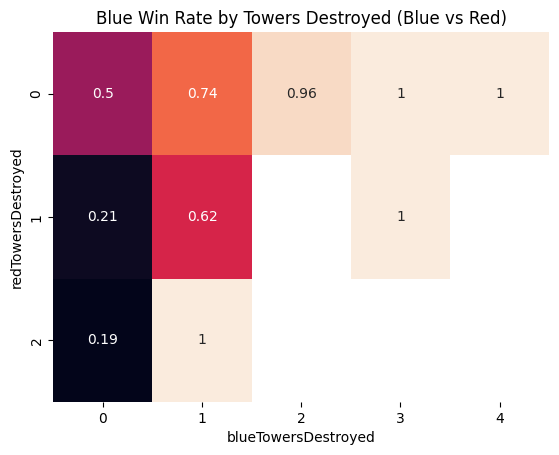

In [18]:
crosstab_towers = pd.crosstab(df_EDA['redTowersDestroyed'], df_EDA['blueTowersDestroyed'], values=df_EDA['blueWins'], aggfunc='mean')
sns.heatmap(crosstab_towers, annot=True, cbar=False)
plt.title('Blue Win Rate by Towers Destroyed (Blue vs Red)')
plt.show();

As expected, these are major factors in the win or loss ; having first blood or the first herald gives you almost a 60% win rate, and having for instance 2 towers to 0 at 10mn gives you at least 80% win rate on average ; even more than having 2 Elite Monsters to 0 (meaning Herald + Drake) at 10mn.

Dropping many useless columns here, as I know (as a LoL player myself) that the data is already represented through other features of the dataset

In [19]:
columns_to_drop = ['gameId', 'redFirstBlood', 'blueEliteMonsters', 'redEliteMonsters', 'redKills',
                   'redDeaths', 'blueAvgLevel', 'redAvgLevel', 'blueGoldPerMin', 'redGoldPerMin', 'blueCSPerMin', 'redCSPerMin', 'redGoldDiff', 'redExperienceDiff']

In [20]:
df_EDA.drop(columns=columns_to_drop, inplace=True)

Many variables are strongly correlated or strongly inversely correlated

# Preprocessing

## First basic preprocessing

### Recreating the df with the EDA's input

In [21]:
df = data.copy()
df.head()

,gameId,blueWins,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons,blueHeralds,blueTowersDestroyed,blueTotalGold,blueAvgLevel,blueTotalExperience,blueTotalMinionsKilled,blueTotalJungleMinionsKilled,blueGoldDiff,blueExperienceDiff,blueCSPerMin,blueGoldPerMin,redWardsPlaced,redWardsDestroyed,redFirstBlood,redKills,redDeaths,redAssists,redEliteMonsters,redDragons,redHeralds,redTowersDestroyed,redTotalGold,redAvgLevel,redTotalExperience,redTotalMinionsKilled,redTotalJungleMinionsKilled,redGoldDiff,redExperienceDiff,redCSPerMin,redGoldPerMin
0,4519157822,0,28,2,1,9,6,11,0,0,0,0,17210,6.6,17039,195,36,643,-8,19.5,1721.0,15,6,0,6,9,8,0,0,0,0,16567,6.8,17047,197,55,-643,8,19.7,1656.7
1,4523371949,0,12,1,0,5,5,5,0,0,0,0,14712,6.6,16265,174,43,-2908,-1173,17.4,1471.2,12,1,1,5,5,2,2,1,1,1,17620,6.8,17438,240,52,2908,1173,24.0,1762.0
2,4521474530,0,15,0,0,7,11,4,1,1,0,0,16113,6.4,16221,186,46,-1172,-1033,18.6,1611.3,15,3,1,11,7,14,0,0,0,0,17285,6.8,17254,203,28,1172,1033,20.3,1728.5
3,4524384067,0,43,1,0,4,5,5,1,0,1,0,15157,7.0,17954,201,55,-1321,-7,20.1,1515.7,15,2,1,5,4,10,0,0,0,0,16478,7.0,17961,235,47,1321,7,23.5,1647.8
4,4436033771,0,75,4,0,6,6,6,0,0,0,0,16400,7.0,18543,210,57,-1004,230,21.0,1640.0,17,2,1,6,6,7,1,1,0,0,17404,7.0,18313,225,67,1004,-230,22.5,1740.4


In [22]:
columns_to_drop = ['gameId', 'redFirstBlood', 'blueEliteMonsters', 'redEliteMonsters', 'redKills',
                   'redDeaths', 'blueAvgLevel', 'redAvgLevel', 'blueGoldPerMin', 'redGoldPerMin', 'blueCSPerMin', 'redCSPerMin', 'redGoldDiff', 'redExperienceDiff']
df.drop(columns=columns_to_drop, inplace=True)

### Train/Test split

In [23]:
from sklearn.model_selection import train_test_split

In [24]:
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['blueWins'], random_state=42)

In [25]:
# let's check the balance of our target in each new dataset

print(train_df['blueWins'].value_counts(normalize=True), "\n")
print(test_df['blueWins'].value_counts(normalize=True))


blueWins
0    0.500949
1    0.499051
Name: proportion, dtype: float64 

blueWins
0    0.501012
1    0.498988
Name: proportion, dtype: float64


### First Basic Feature Engineering

Very high correlation between kills and assists across teams and even within a single team, so let's merge them into a single variable

In [26]:
def feature_engineering(df):
    df['blueKillsAssists'] = df['blueKills'] + df['blueAssists']
    df['redKillsAssists'] = df['blueDeaths'] + df['redAssists']
    df.drop(columns=['blueKills', 'blueAssists', 'blueDeaths', 'redAssists'], inplace=True)
    return df

### Final first basic preprocessing function

In [27]:
def preprocessing(df):
    
    df = feature_engineering(df)

    X = df.drop('blueWins', axis=1)
    y = df['blueWins']

    print(f'Our y target has this classes distribution :\n{y.value_counts(normalize=True)}\n')

    return X, y

In [28]:
X_train, y_train = preprocessing(train_df)
X_test, y_test = preprocessing(test_df)

Our y target has this classes distribution :
blueWins
0    0.500949
1    0.499051
Name: proportion, dtype: float64

Our y target has this classes distribution :
blueWins
0    0.501012
1    0.498988
Name: proportion, dtype: float64



## First basic modeling

In [29]:
from sklearn.ensemble import RandomForestClassifier

In [30]:
model_1 = RandomForestClassifier(random_state=42)

In [31]:
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.model_selection import learning_curve

In [32]:
# definition of an evaluation function

def evaluation(model, X_train, y_train, X_test, y_test):
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f'Confusion matrix:\n{confusion_matrix(y_test, y_pred)}\n')
    print(f'Classification report:\n{classification_report(y_test, y_pred)}')

In [33]:
evaluation(model_1, X_train, y_train, X_test, y_test)

Confusion matrix:
[[724 266]
 [283 703]]

Classification report:
              precision    recall  f1-score   support

           0       0.72      0.73      0.73       990
           1       0.73      0.71      0.72       986

    accuracy                           0.72      1976
   macro avg       0.72      0.72      0.72      1976
weighted avg       0.72      0.72      0.72      1976



Good scores for a very basic model, let's check the learning curve to check over/under-fitting

In [34]:
# learning curve

N, train_scores, val_scores = learning_curve(model_1, X_train, y_train, cv=4, train_sizes=np.linspace(0.1, 1, 10), scoring='f1')

val_scores.mean(axis=1)

array([0.71223662, 0.71610794, 0.71737046, 0.71803615, 0.72045787,
       0.72023052, 0.7173386 , 0.72014105, 0.72156945, 0.72302028])

## First evaluation and feature importance

Let's add this learning curve to our evaluation function 

In [35]:
def evaluation(model, X_train, y_train, X_test, y_test):
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f'Confusion matrix:\n{confusion_matrix(y_test, y_pred)}\n')
    print(f'Classification report:\n{classification_report(y_test, y_pred)}')

    # this part was added later, after the first basic model had been run
    N, train_scores, val_scores = learning_curve(model, X_train, y_train, 
                                                 cv=5,
                                                 train_sizes=np.linspace(0.1, 1, 10), 
                                                 scoring='f1') 
    
    plt.figure(figsize=(15,10))
    plt.plot(N, train_scores.mean(axis=1), label='train score')
    plt.plot(N, val_scores.mean(axis=1), label='val score')
    plt.legend()
    plt.show();

Confusion matrix:
[[724 266]
 [283 703]]

Classification report:
              precision    recall  f1-score   support

           0       0.72      0.73      0.73       990
           1       0.73      0.71      0.72       986

    accuracy                           0.72      1976
   macro avg       0.72      0.72      0.72      1976
weighted avg       0.72      0.72      0.72      1976



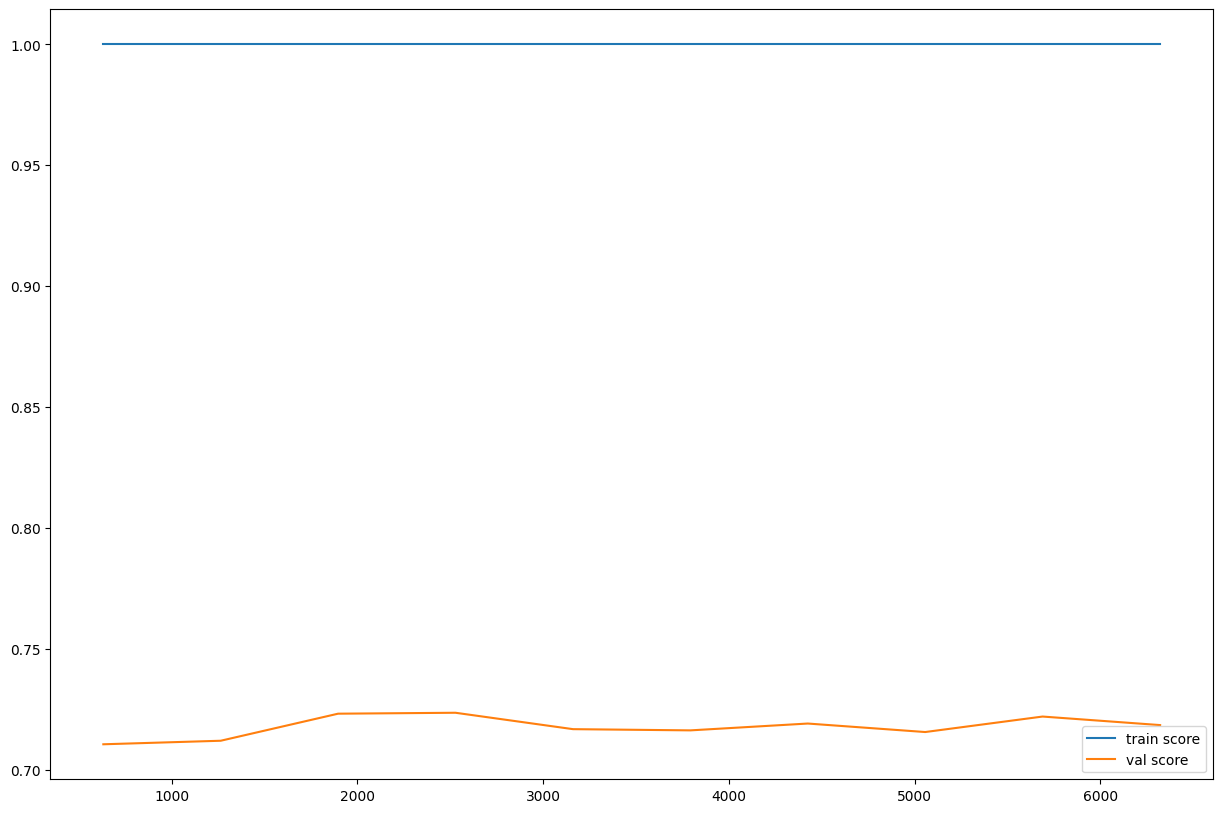

In [36]:
evaluation(model_1, X_train, y_train, X_test, y_test)

Good score but obviously we have an important over-fitting displayed here. Let's now tailor our dataset so that we can try to fit that

Let's first look at our feature importances from our first basic model

<Axes: >

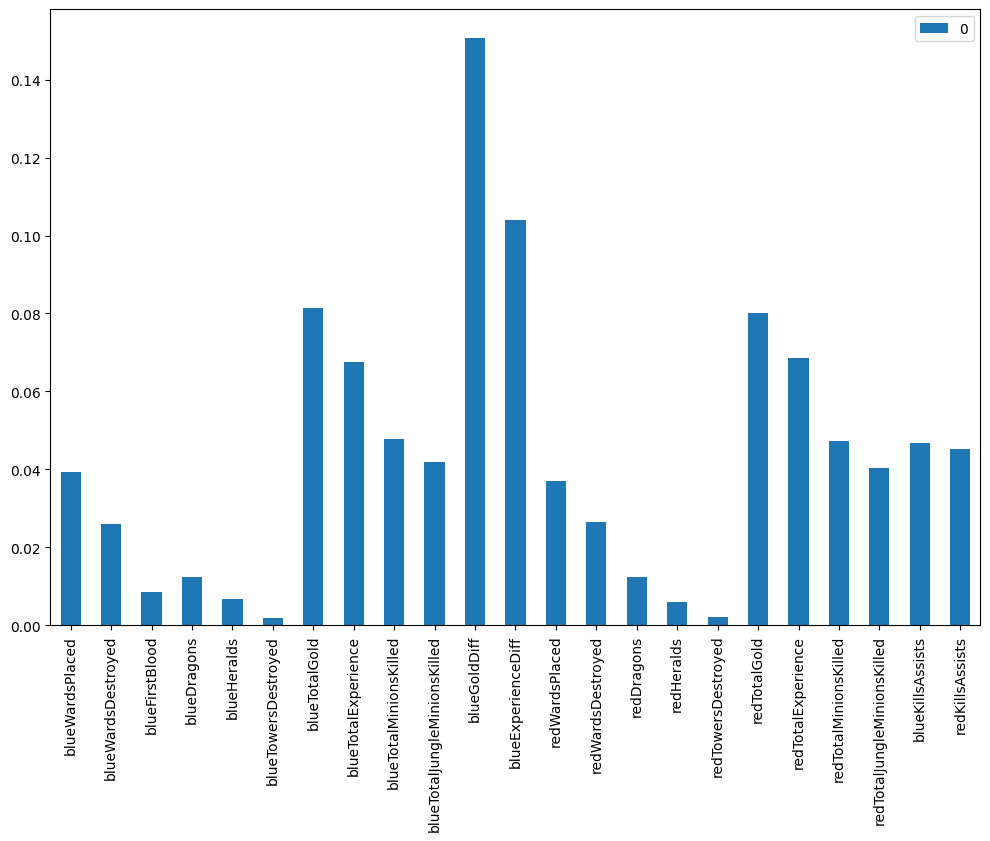

In [37]:
pd.DataFrame(model_1.feature_importances_, index=X_train.columns).plot.bar(figsize=(12,8))

Surprising result because although GoldDiff and ExperienceDiff are the result of killing Dragons, Heralds, Towers and having First Blood etc... I didn't expect those features to be so far back in terms of importance, even behind Wards Placed & Destroyed. As a player I know they are of great importance, so I'm not going to remove them for now.

Let's look at correlations in our dataset and see if we can remove some

## 2nd preprocessing after our first model

### Feature Selection

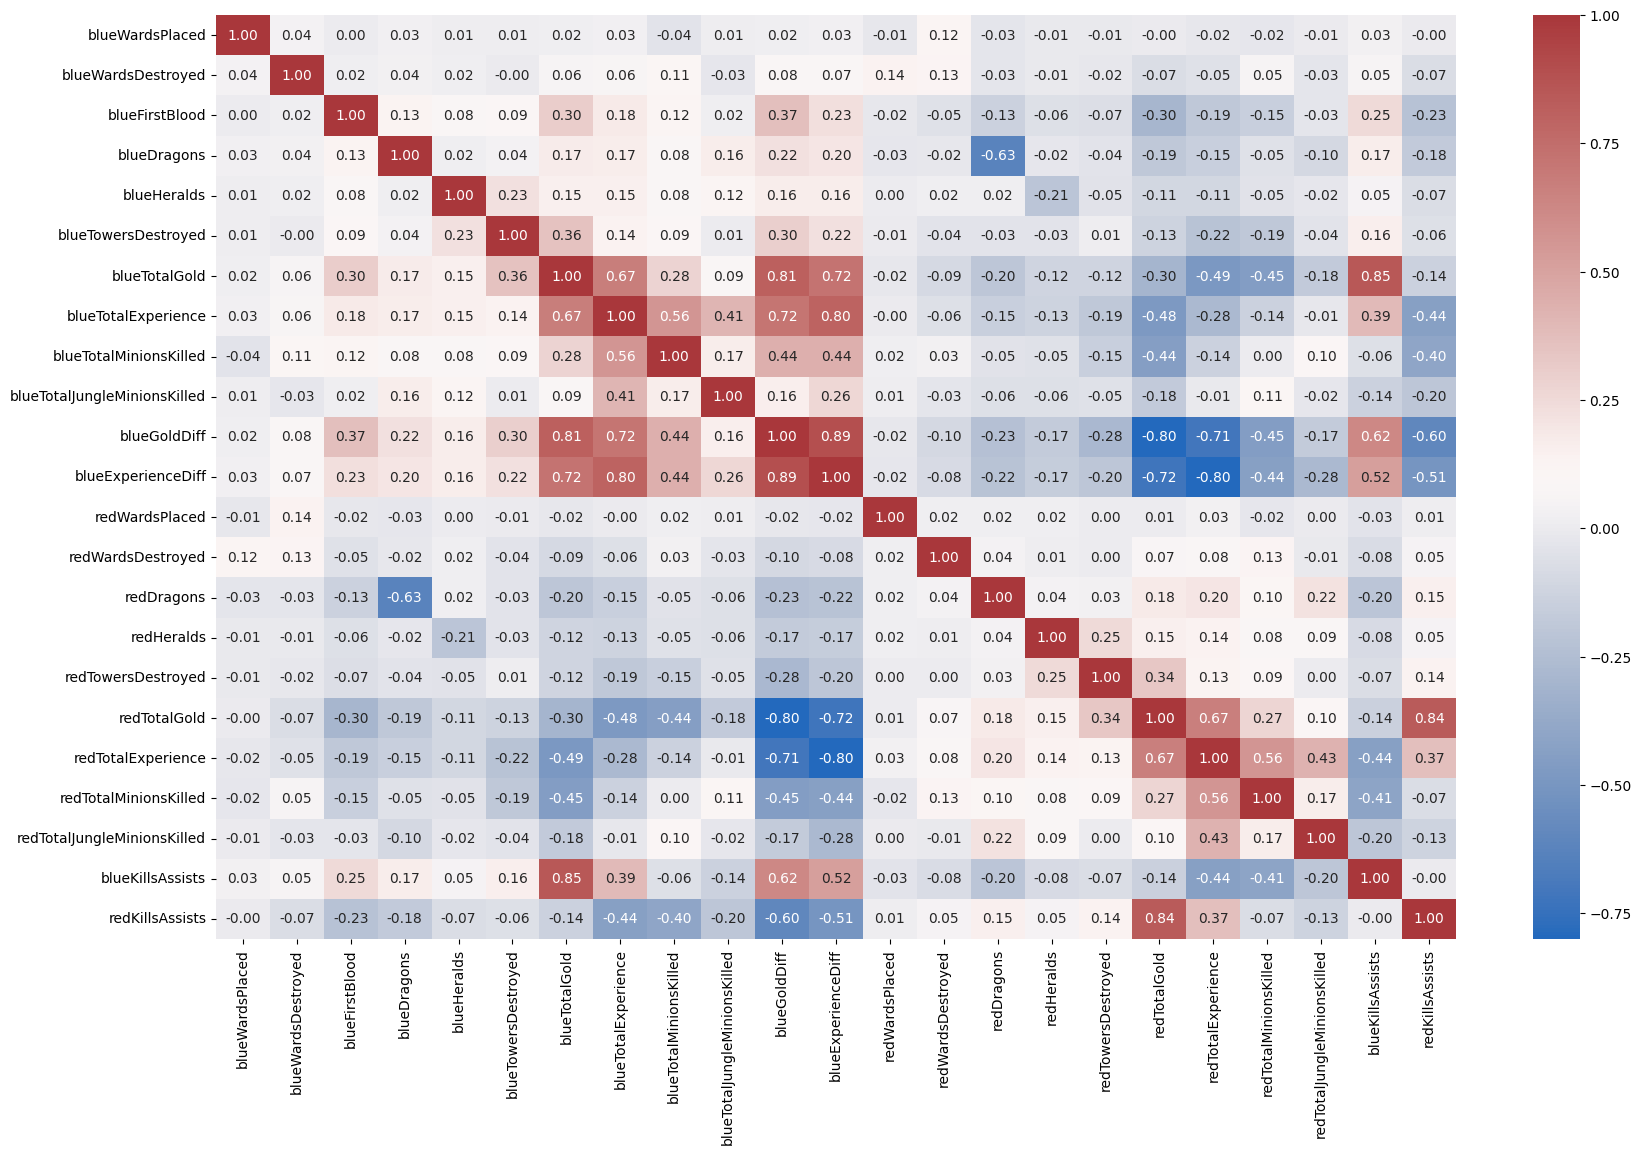

In [38]:
plt.figure(figsize=(20, 12))
sns.heatmap(X_train.corr(), annot=True, cmap='vlag', fmt='.2f');

We can see many high correlations (or inverse correlations) between variables (> 0.5 let's say).

In regards to this heatmap of correlations, we drop some features :

- TotalGold and TotalExperience from both sides are removed, since blueGoldDiff and blueExperienceDiff already give this information (correlation of 0.7 or 0.8)
- Some features have so little correlations that I suspect very low variance too (Wards features, but also TotalJungleMinionsKilled) : we can look at our outliers after, and/or add a VarianceThreshold in a new model consisting in a pipeline

I'll re-recreate my dataframe (but named df_2) one last time here for the sake of keeping my first evaluation graph (instead of just changing the columns etc from the columns above and re-run), to showcase my thought process. In a normal set-up, I wouldn't rewrite everything. 

In [39]:
df_2 = data.copy()

In [40]:
columns_to_drop = ['gameId', 'redFirstBlood', 'blueEliteMonsters', 'redEliteMonsters', 'redKills', 'blueTotalExperience', 'blueTotalGold', 'redTotalExperience', 'redTotalGold',
                   'redDeaths', 'blueAvgLevel', 'redAvgLevel', 'blueGoldPerMin', 'redGoldPerMin', 'blueCSPerMin', 'redCSPerMin', 'redGoldDiff', 'redExperienceDiff']
df_2.drop(columns=columns_to_drop, inplace=True)

### Removing outliers

This is especially important because in the first 10 minutes of the game, when a team gives up, they stay in base and let the ennemies take kills, towers, objectives... that would never happen in the first 10 minutes of a regular game. So it's important we remove those outliers in key continuous features

Special case of TowersDestroyed features, as they are discrete columns but there are clearly outliers. Also, I know as a player than having 2 towers destroyed at 10mn is odd enough, let alone 3 or 4 towers which are clearly signs of giving up from one team. 

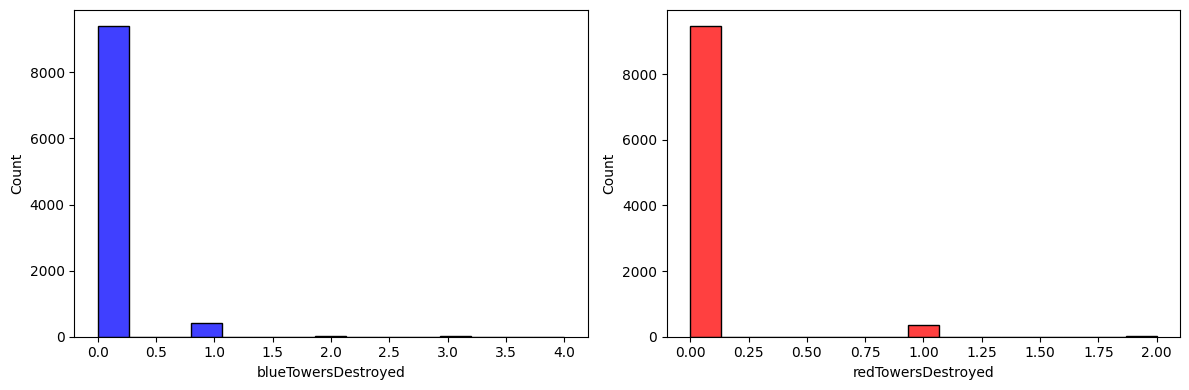

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=df_2, x='blueTowersDestroyed', ax=axes[0], color='blue')
sns.histplot(data=df_2, x='redTowersDestroyed', ax=axes[1], color='red')

plt.tight_layout()
plt.show();

So lets remove 3 or more towers destroyed for blue (since red already has only 2 towers destroyed max in the raw data)

In [42]:
df_2 = df_2[~df_2['blueTowersDestroyed'].isin([3, 4])]
df_2['blueTowersDestroyed'].value_counts()

blueTowersDestroyed
0    9415
1     429
2      27
Name: count, dtype: int64

In [43]:
discrete_variables = ['blueFirstBlood', 'blueWins', 'blueDragons', 'blueHeralds', 'redHeralds', 'redDragons', 'blueTowersDestroyed', 'redTowersDestroyed']

In [44]:
# removing outliers using z_score
df_2_no_outliers = df_2.copy()

outliers_cols = [col for col in df_2_no_outliers.columns if col not in discrete_variables]

z_scores = np.abs(stats.zscore(df_2_no_outliers[outliers_cols]))
threshold = 4

df_2_no_outliers = df_2_no_outliers[(z_scores < threshold).all(axis=1)]

print(f"Original shape: {df_2.shape}")
print(f"After removing outliers, the new shape is: {df_2_no_outliers.shape}")

Original shape: (9871, 22)
After removing outliers, the new shape is: (9394, 22)


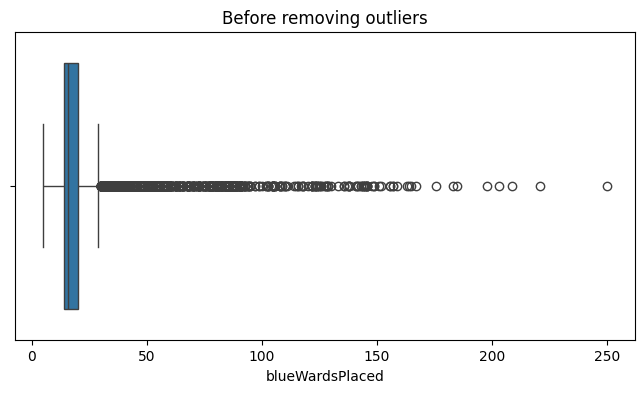

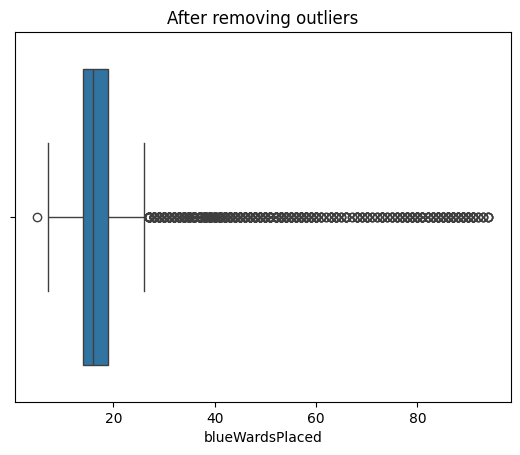

In [45]:
# Example of the result of removing outliers for Wards

plt.figure(figsize=(8, 4))
sns.boxplot(x=df_2['blueWardsPlaced'])
plt.title("Before removing outliers")
plt.show()

sns.boxplot(x=df_2_no_outliers['blueWardsPlaced'])
plt.title("After removing outliers")
plt.show()

### Re-evaluating after more preprocessing

In [46]:
train_df_2, test_df_2 = train_test_split(df_2_no_outliers, test_size=0.2, stratify=df_2_no_outliers['blueWins'], random_state=42)

In [47]:
X_train_2, y_train_2 = preprocessing(train_df_2)
X_test_2, y_test_2 = preprocessing(test_df_2)

Our y target has this classes distribution :
blueWins
0    0.500865
1    0.499135
Name: proportion, dtype: float64

Our y target has this classes distribution :
blueWins
0    0.500798
1    0.499202
Name: proportion, dtype: float64



Let's now add a pipeline to our basic RandomForest model, to add transformers to fight our over-fitting

In [48]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold


In [49]:
model = make_pipeline(PolynomialFeatures(2),
                      VarianceThreshold(threshold=0.0),
                      SelectKBest(f_classif, k=4),
                      RandomForestClassifier(random_state=42))

In [50]:
# pasting again the function to change the X_train etc inside to match my new name

def evaluation(model, X_train, y_train, X_test, y_test):
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f'Confusion matrix:\n{confusion_matrix(y_test, y_pred)}\n')
    print(f'Classification report:\n{classification_report(y_test, y_pred)}')

    # this part was added later, after the first basic model had been run
    N, train_scores, val_scores = learning_curve(model, X_train, y_train, 
                                                 cv=3,
                                                 train_sizes=np.linspace(0.1, 1, 10), 
                                                 scoring='f1') 
    
    plt.figure(figsize=(15, 10))
    plt.plot(N, train_scores.mean(axis=1), label='train score')
    plt.plot(N, val_scores.mean(axis=1), label='val score')
    plt.legend()
    plt.show();

Confusion matrix:
[[646 295]
 [291 647]]

Classification report:
              precision    recall  f1-score   support

           0       0.69      0.69      0.69       941
           1       0.69      0.69      0.69       938

    accuracy                           0.69      1879
   macro avg       0.69      0.69      0.69      1879
weighted avg       0.69      0.69      0.69      1879



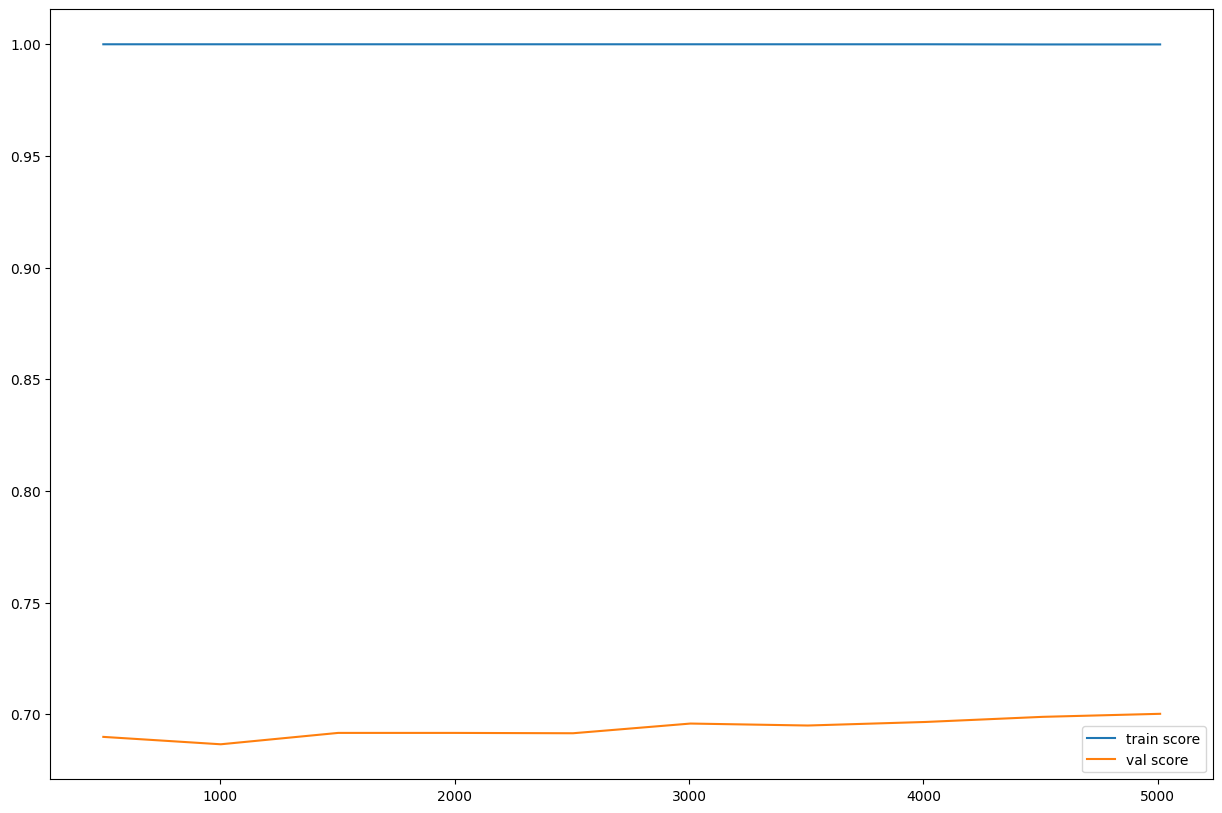

In [51]:
evaluation(model, X_train_2, y_train_2, X_test_2, y_test_2)

Sadly, our preprocessing made the CV results slightly worse, although the val scores curve is ascending. But we still clearly have an over-fitting issue! Let's now try different models and proper modeling with searching for hyperparameters.

# Final Modeling

## Testing various models with our preprocessed dataset

In [52]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

In [53]:
preprocessor = make_pipeline(PolynomialFeatures(2),
                      VarianceThreshold(threshold=0.0),
                      SelectKBest(f_classif, k=4))

In [54]:
RandomForest = make_pipeline(preprocessor,
                             RandomForestClassifier(random_state=42))

AdaBoost = make_pipeline(preprocessor,
                         AdaBoostClassifier(random_state=42))

LogReg = make_pipeline(preprocessor,
                       StandardScaler(),
                       LogisticRegression(random_state=42))

XGBoost = make_pipeline(preprocessor,
                        XGBClassifier(random_state=42))

SVM = make_pipeline(preprocessor,
                    StandardScaler(),
                    SVC(random_state=42))

RandomForest 

Confusion matrix:
[[646 295]
 [291 647]]

Classification report:
              precision    recall  f1-score   support

           0       0.69      0.69      0.69       941
           1       0.69      0.69      0.69       938

    accuracy                           0.69      1879
   macro avg       0.69      0.69      0.69      1879
weighted avg       0.69      0.69      0.69      1879



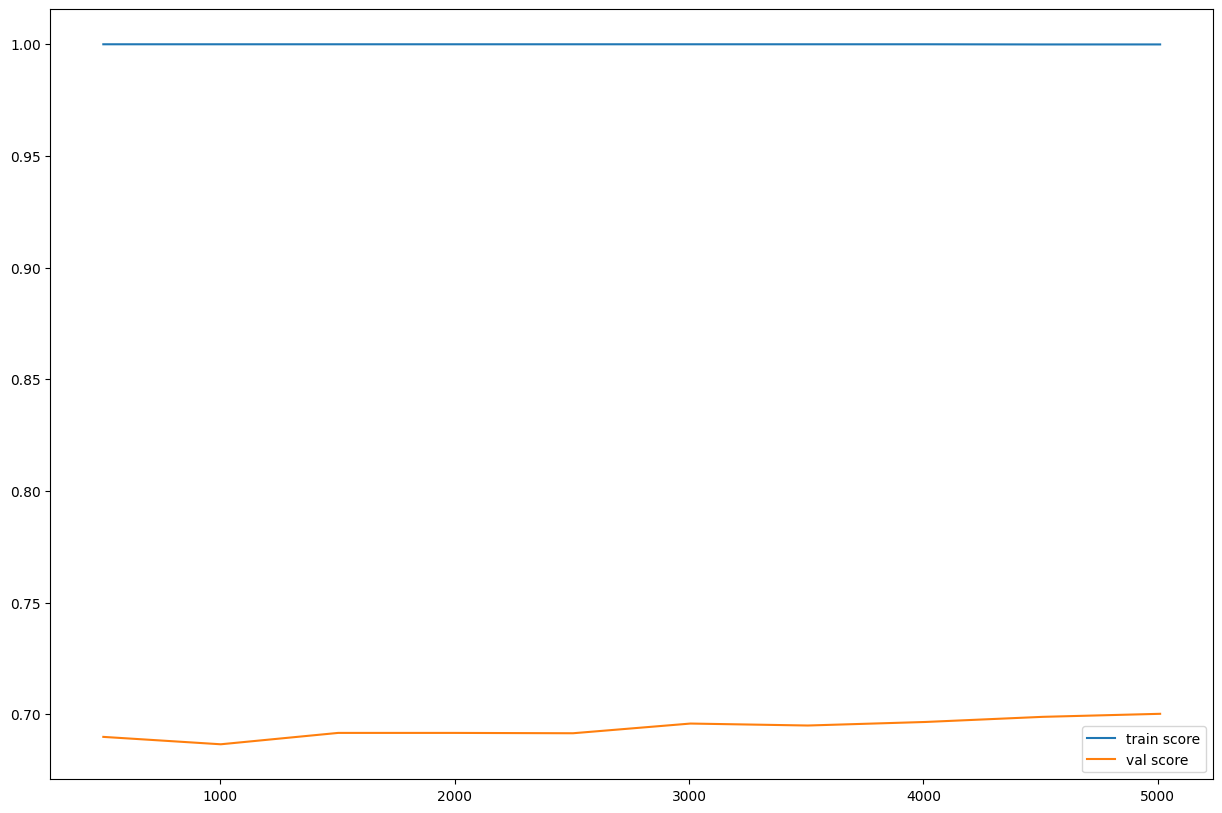

AdaBoost 

Confusion matrix:
[[701 240]
 [294 644]]

Classification report:
              precision    recall  f1-score   support

           0       0.70      0.74      0.72       941
           1       0.73      0.69      0.71       938

    accuracy                           0.72      1879
   macro avg       0.72      0.72      0.72      1879
weighted avg       0.72      0.72      0.72      1879



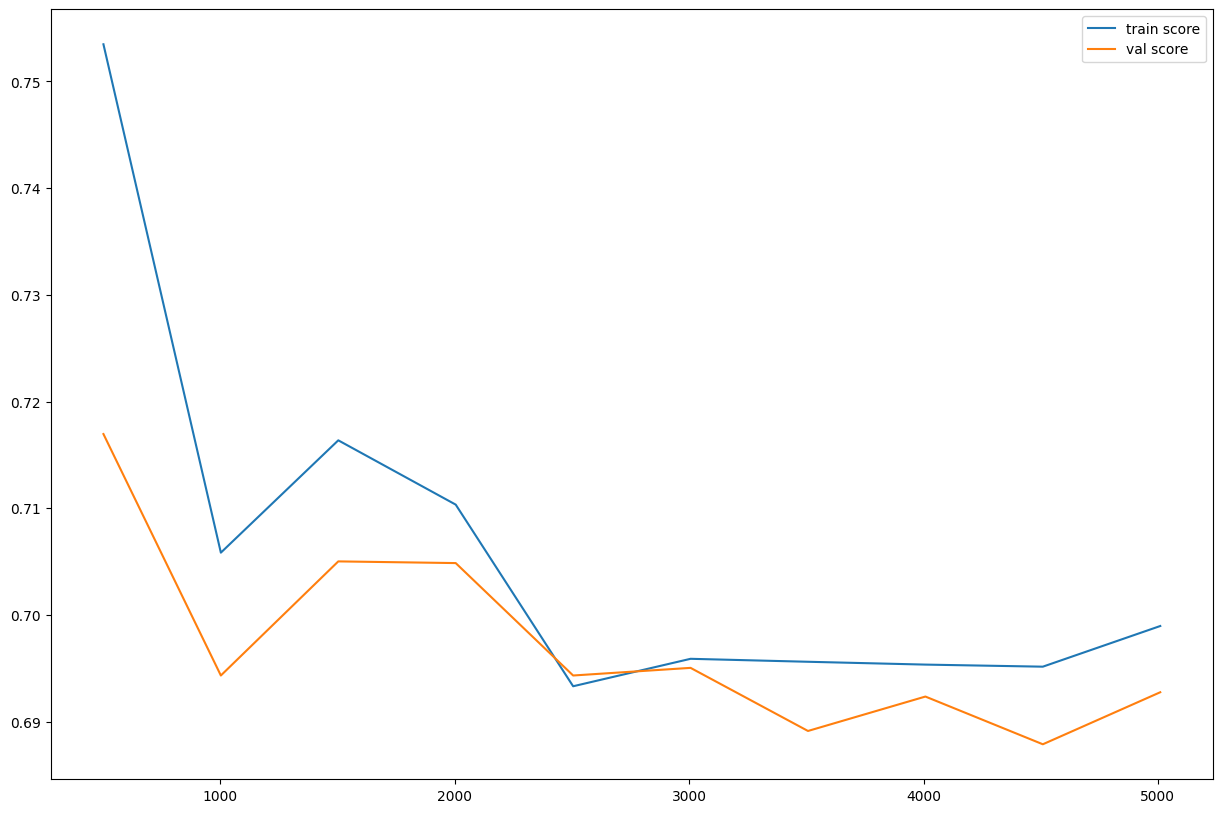

LogReg 

Confusion matrix:
[[673 268]
 [269 669]]

Classification report:
              precision    recall  f1-score   support

           0       0.71      0.72      0.71       941
           1       0.71      0.71      0.71       938

    accuracy                           0.71      1879
   macro avg       0.71      0.71      0.71      1879
weighted avg       0.71      0.71      0.71      1879



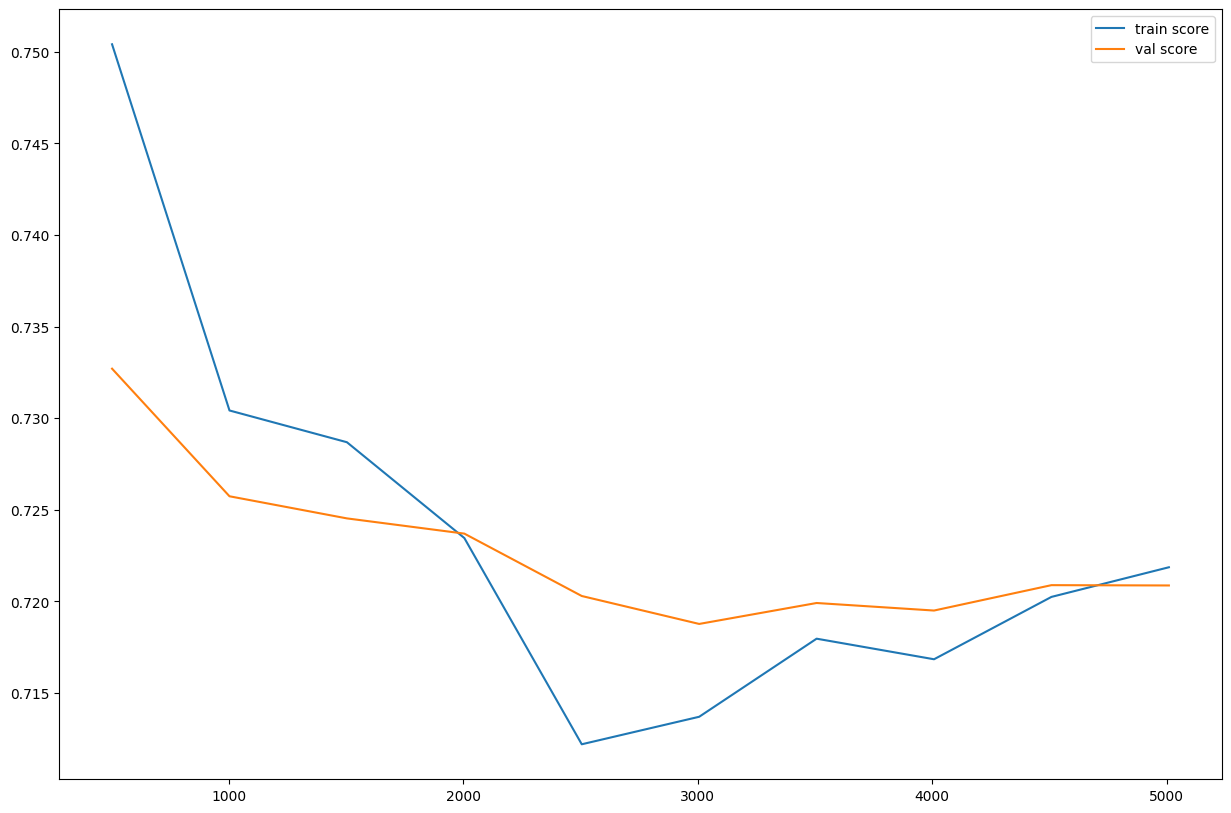

XGBoost 

Confusion matrix:
[[673 268]
 [305 633]]

Classification report:
              precision    recall  f1-score   support

           0       0.69      0.72      0.70       941
           1       0.70      0.67      0.69       938

    accuracy                           0.70      1879
   macro avg       0.70      0.70      0.69      1879
weighted avg       0.70      0.70      0.69      1879



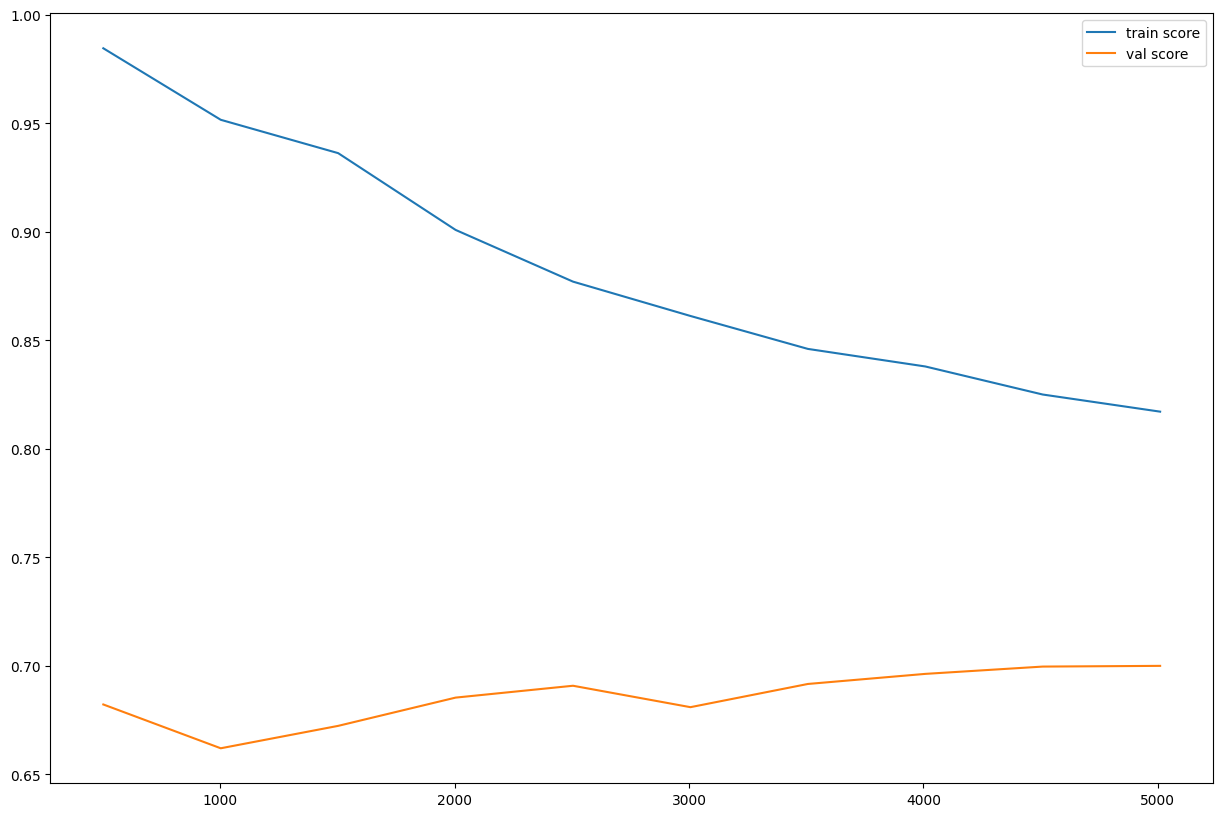

SVM 

Confusion matrix:
[[681 260]
 [278 660]]

Classification report:
              precision    recall  f1-score   support

           0       0.71      0.72      0.72       941
           1       0.72      0.70      0.71       938

    accuracy                           0.71      1879
   macro avg       0.71      0.71      0.71      1879
weighted avg       0.71      0.71      0.71      1879



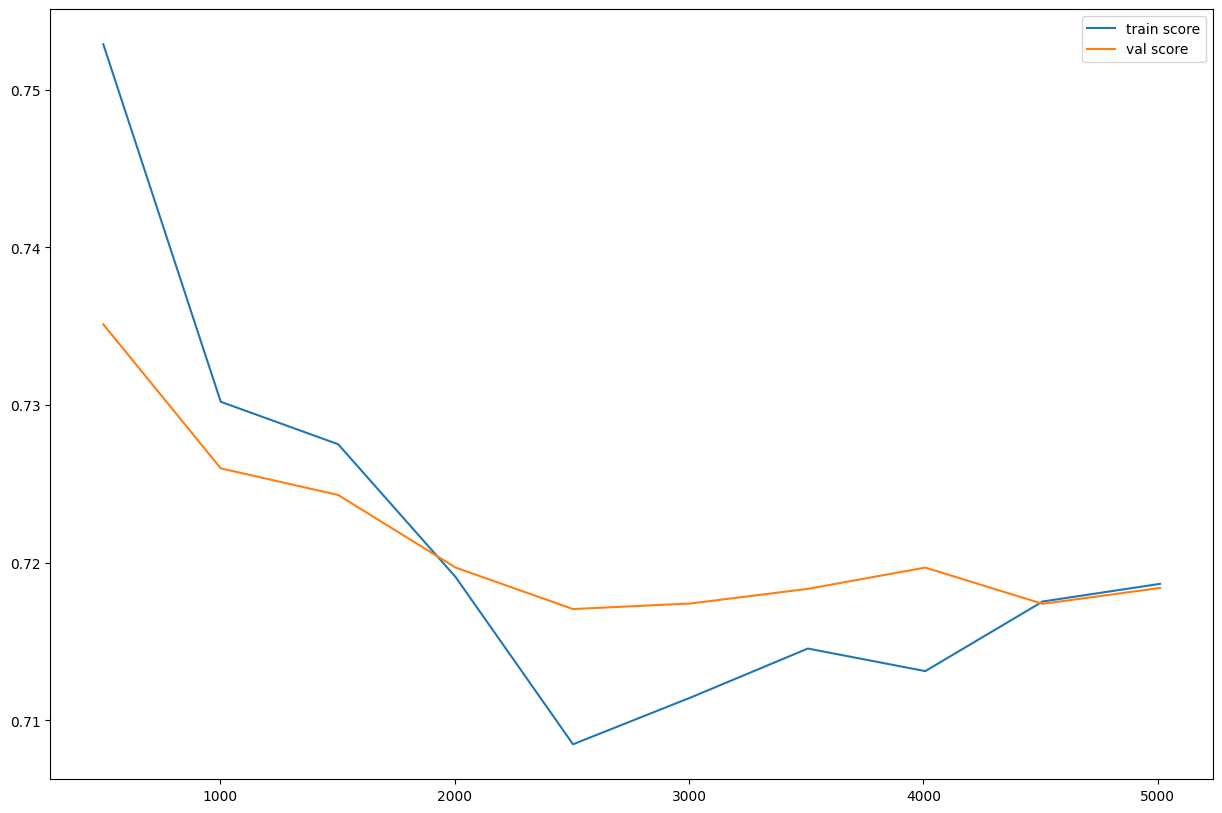

In [55]:
models = {
    'RandomForest': RandomForest,
    'AdaBoost': AdaBoost,
    'LogReg': LogReg,
    'XGBoost': XGBoost,
    'SVM': SVM
}

for name, model in models.items():
    print(name, "\n")
    evaluation(model, X_train_2, y_train_2, X_test_2, y_test_2)

Looking at our first results, let's focus on LogisticRegression & SVM in our case

## Optimization

### LogisticRegression

#### First GridSearch

In [56]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [57]:
LogReg # showcasing the pipeline to look at the steps for our gridsearch/randomizedsearch

,steps,"[('pipeline', ...), ('standardscaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('polynomialfeatures', ...), ('variancethreshold', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,degree,2
,interaction_only,False
,include_bias,True


In [58]:
LogReg.steps # same

[('pipeline',
  Pipeline(steps=[('polynomialfeatures', PolynomialFeatures()),
                  ('variancethreshold', VarianceThreshold()),
                  ('selectkbest', SelectKBest(k=4))])),
 ('standardscaler', StandardScaler()),
 ('logisticregression', LogisticRegression(random_state=42))]

In [59]:
LogReg_hyperparams = {
    'pipeline__polynomialfeatures__degree': [2, 3],
    'pipeline__selectkbest__k': range(4,7),
    'logisticregression__penalty': ['l1', 'l2'],
    'logisticregression__C': [0.1, 1, 10],
    'logisticregression__solver': ['liblinear']
}

In [60]:
LogReg_grid = GridSearchCV(LogReg, LogReg_hyperparams, cv=3, scoring='f1')

LogReg_grid.fit(X_train_2, y_train_2)

LogReg_grid.best_params_

{'logisticregression__C': 1,
 'logisticregression__penalty': 'l1',
 'logisticregression__solver': 'liblinear',
 'pipeline__polynomialfeatures__degree': 2,
 'pipeline__selectkbest__k': 6}

In [61]:
y_pred = LogReg_grid.predict(X_test_2)

print(classification_report(y_test_2, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.72      0.72       941
           1       0.72      0.72      0.72       938

    accuracy                           0.72      1879
   macro avg       0.72      0.72      0.72      1879
weighted avg       0.72      0.72      0.72      1879



Confusion matrix:
[[676 265]
 [260 678]]

Classification report:
              precision    recall  f1-score   support

           0       0.72      0.72      0.72       941
           1       0.72      0.72      0.72       938

    accuracy                           0.72      1879
   macro avg       0.72      0.72      0.72      1879
weighted avg       0.72      0.72      0.72      1879



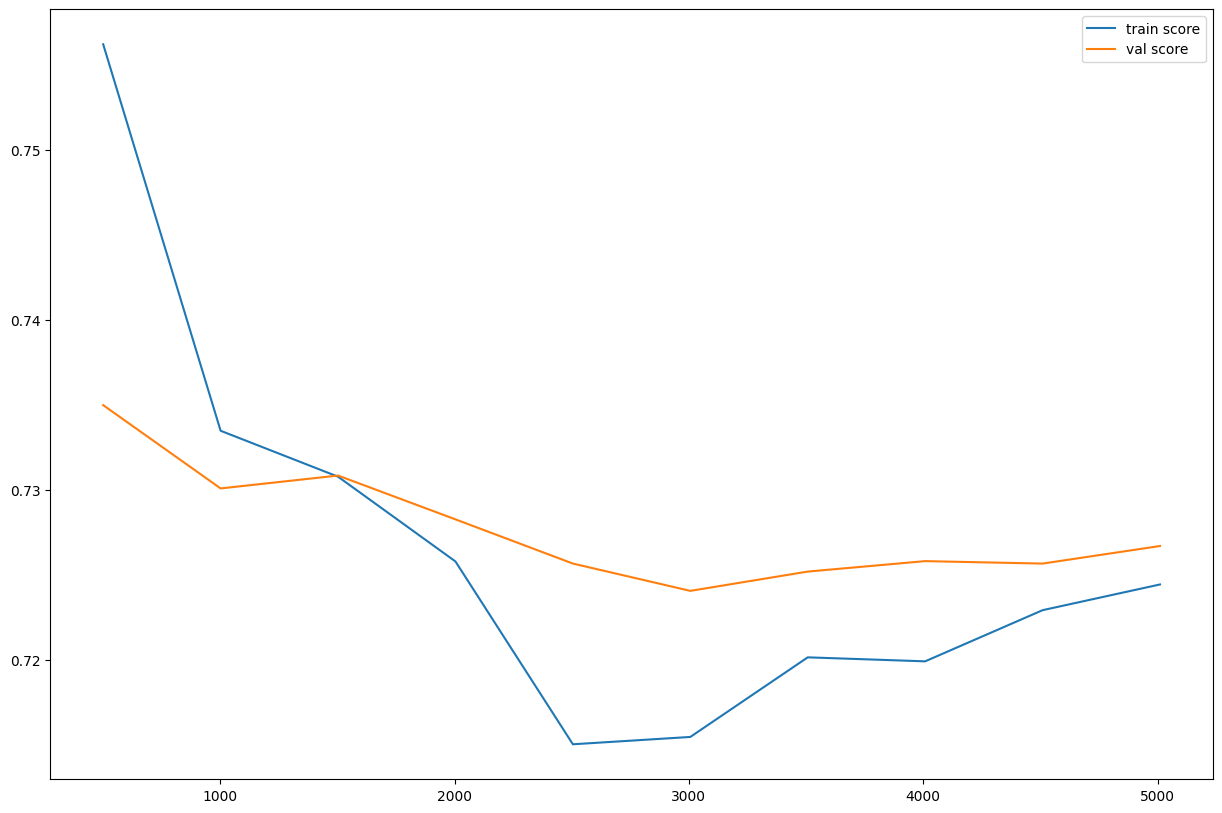

In [62]:
evaluation(LogReg_grid.best_estimator_, X_train_2, y_train_2, X_test_2, y_test_2)

#### Loop of RandomizedSearches

This time I'll try to write a loop of RandomizedSearches to iterate and reduce progressively our space around the best params we find at each iteration

In [63]:
LogReg_grid.best_params_

{'logisticregression__C': 1,
 'logisticregression__penalty': 'l1',
 'logisticregression__solver': 'liblinear',
 'pipeline__polynomialfeatures__degree': 2,
 'pipeline__selectkbest__k': 6}

In [64]:
# def of the first hyperparams space
initial_space = {
    'pipeline__polynomialfeatures__degree': range(2, 5),
    'pipeline__selectkbest__k': range(4, 70, 5),
    'logisticregression__penalty': ['l1', 'l2'],
    'logisticregression__C': np.arange(0.1, 10, 1),
    'logisticregression__solver': ['liblinear']
}

# initial count
global_best_score = 0
global_best_params = None
search_space = initial_space
final_best_estimator = None

for i in range(5): # 5 iterations
    print(f'\n** RandomizedSearch round {i+1}')

    grid = RandomizedSearchCV(LogReg, search_space, scoring='f1', cv=3, n_iter=20, random_state=i)

    grid.fit(X_train_2, y_train_2)

    best_estimator = grid.best_estimator_
    best_params = grid.best_params_
    best_score = grid.best_score_

    print(f'--> Best params are {best_params}')
    print(f'--> Mean CV f1 score is {best_score:.3f}')

    # if our score for this run is better than the global one, we change it
    if best_score > global_best_score:
        global_best_score = best_score
        global_best_params = best_params
        global_best_estimator = best_estimator
        print(f'New best global score is {global_best_score}')
    
    # now we progressively reduce our space to the best params
    degree = best_params['pipeline__polynomialfeatures__degree']
    k = best_params['pipeline__selectkbest__k']
    C = best_params['logisticregression__C']
    search_space = {
        'pipeline__polynomialfeatures__degree': [max(2, degree-1), degree, degree+1],
        'pipeline__selectkbest__k': range(max(4, k-4), min(70, k+4)),
        'logisticregression__penalty': [best_params['logisticregression__penalty']],
        'logisticregression__C': np.arange(max(0.1, C-0.5), min(10, C+0.5), 0.2),
        'logisticregression__solver': ['liblinear']
    }
    
print(f"\nFinal best params after iterative refinement: {global_best_params}")


** RandomizedSearch round 1
--> Best params are {'pipeline__selectkbest__k': 64, 'pipeline__polynomialfeatures__degree': 2, 'logisticregression__solver': 'liblinear', 'logisticregression__penalty': 'l2', 'logisticregression__C': np.float64(7.1)}
--> Mean CV f1 score is 0.727
New best global score is 0.7272879584157154

** RandomizedSearch round 2
--> Best params are {'pipeline__selectkbest__k': 67, 'pipeline__polynomialfeatures__degree': 2, 'logisticregression__solver': 'liblinear', 'logisticregression__penalty': 'l2', 'logisticregression__C': np.float64(7.4)}
--> Mean CV f1 score is 0.728
New best global score is 0.7283128250871888

** RandomizedSearch round 3
--> Best params are {'pipeline__selectkbest__k': 67, 'pipeline__polynomialfeatures__degree': 2, 'logisticregression__solver': 'liblinear', 'logisticregression__penalty': 'l2', 'logisticregression__C': np.float64(7.500000000000001)}
--> Mean CV f1 score is 0.728

** RandomizedSearch round 4
--> Best params are {'pipeline__select

Spent some time writing the function and it's not that useful, since the difference in scores is so low. In the future I'll just manually change some parameters to tune my RandomizedSearch.

#### Precision recall curve

In [65]:
from sklearn.metrics import precision_recall_curve

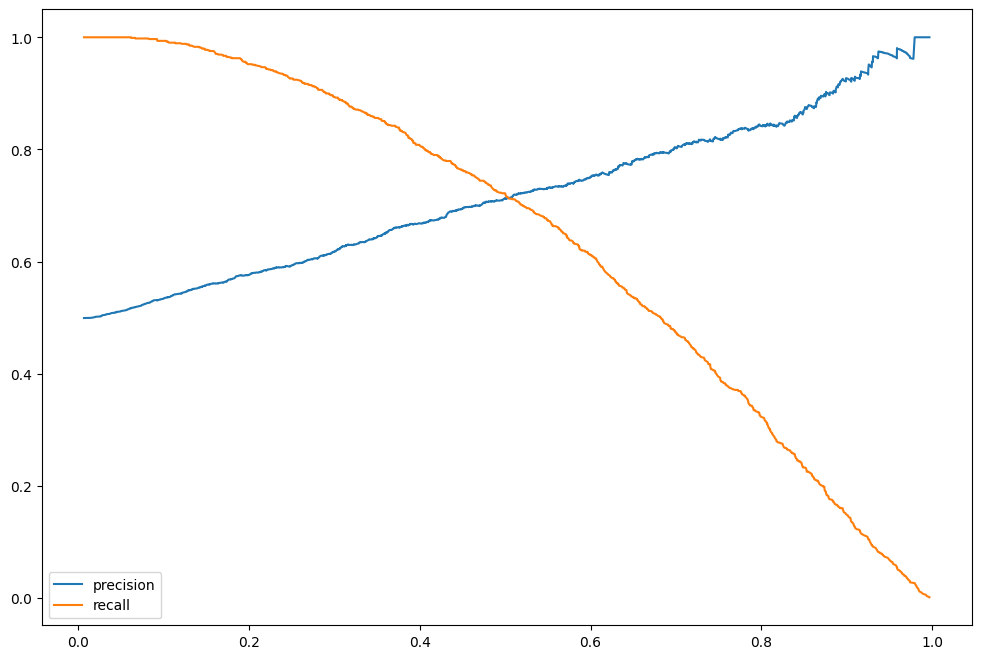

In [66]:
precision, recall, threshold = precision_recall_curve(y_test_2, global_best_estimator.predict_proba(X_test_2)[:, 1])

plt.figure(figsize=(12, 8))
plt.plot(threshold, precision[:-1], label='precision')
plt.plot(threshold, recall[:-1], label='recall')
plt.legend()
plt.show();

We can now see the threshold (approx 0.5) where we can 'sacrifice' a bit of our recall score if we want more precision, or vice-versa. Or we can just keep our simple f1 score.

Confusion matrix:
[[669 272]
 [262 676]]

Classification report:
              precision    recall  f1-score   support

           0       0.72      0.71      0.71       941
           1       0.71      0.72      0.72       938

    accuracy                           0.72      1879
   macro avg       0.72      0.72      0.72      1879
weighted avg       0.72      0.72      0.72      1879



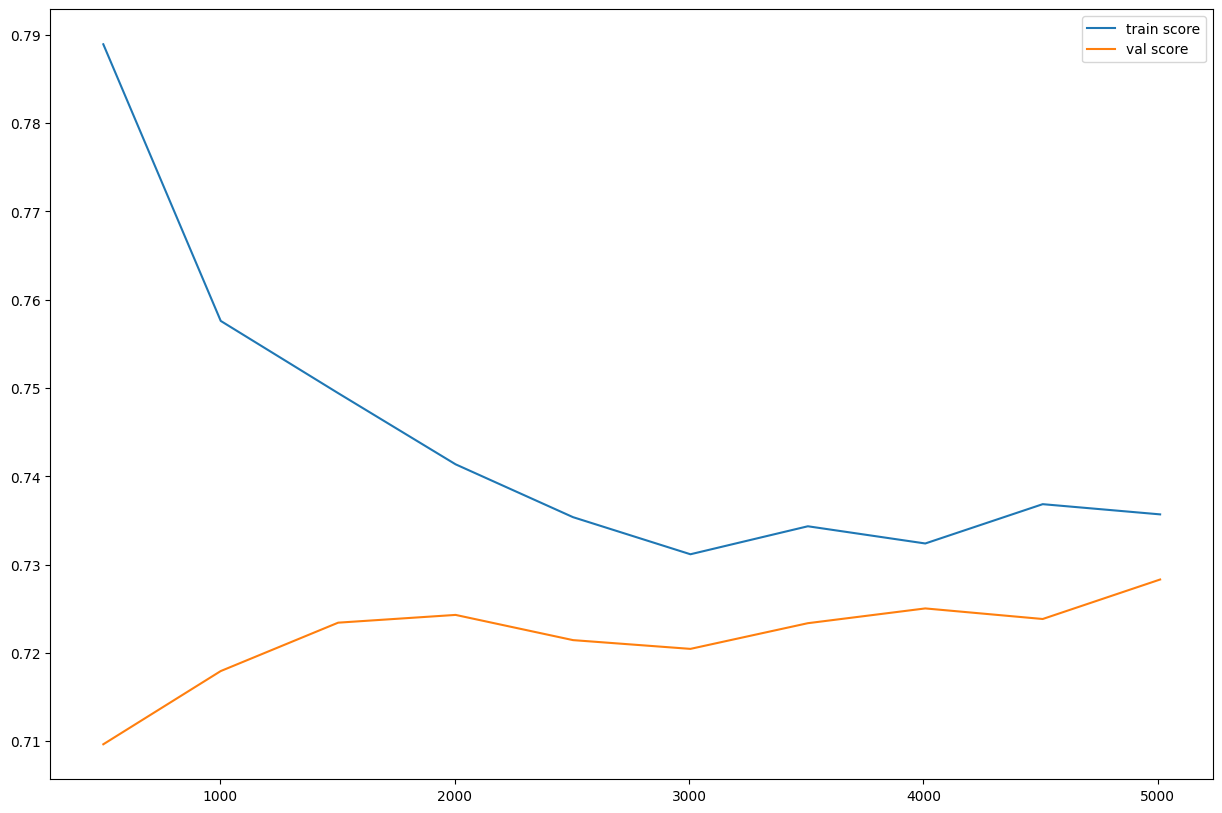

In [67]:
evaluation(global_best_estimator, X_train_2, y_train_2, X_test_2, y_test_2)

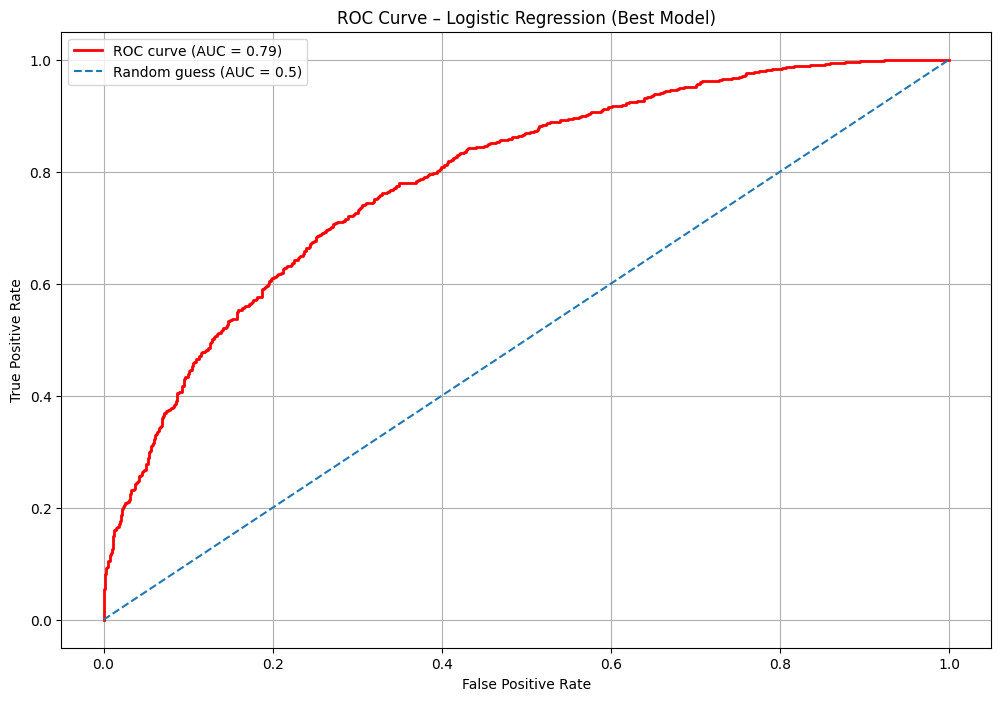

In [68]:
from sklearn.metrics import roc_curve, auc

y_score = global_best_estimator.predict_proba(X_test_2)[:, 1]  # proba of class 1

FPR, TPR, thresholds = roc_curve(y_test_2, y_score)
AUC = auc(FPR, TPR)

plt.figure(figsize=(12, 8))
plt.plot(FPR, TPR, c='r', lw=2, label=f'ROC curve (AUC = {AUC:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random guess (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Logistic Regression (Best Model)')
plt.legend()
plt.grid(True)
plt.show();

In [69]:
# Final evaluation score of accuracy : 

global_best_estimator.score(X_test_2, y_test_2)

0.7158062799361362

Unfortunately the preprocessing and modeling couldn't improve much our scores.

Yet, with 10 minutes of in-game data, our logistic regression model predicts the correct match outcome with ~72 % accuracy, which is relatively good. We also achieve a ROC–AUC of  0.79 — indicating strong ability to separate winning from losing games.

### SVC

For the SVC model, same framework as the LogisticRegression one, but without the "for" loop for the hyperparameters optimization.

In [70]:
SVM

,steps,"[('pipeline', ...), ('standardscaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('polynomialfeatures', ...), ('variancethreshold', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,degree,2
,interaction_only,False
,include_bias,True


In [71]:
SVM.steps

[('pipeline',
  Pipeline(steps=[('polynomialfeatures', PolynomialFeatures()),
                  ('variancethreshold', VarianceThreshold()),
                  ('selectkbest', SelectKBest(k=4))])),
 ('standardscaler', StandardScaler()),
 ('svc', SVC(random_state=42))]

In [72]:
SVM_hyperparams = {
    'pipeline__polynomialfeatures__degree': [2],
    'pipeline__selectkbest__k': range(5, 100, 5),
    'svc__C': [0.01, 0.1, 1, 10, 100],
    'svc__kernel': ['linear', 'rbf']
}

SVC_grid = RandomizedSearchCV(SVM,
                              SVM_hyperparams,
                              scoring='f1',
                              random_state=42,
                              n_iter=10,
                              cv=3)

SVC_grid.fit(X_train_2, y_train_2)

print(SVC_grid.best_params_)

{'svc__kernel': 'linear', 'svc__C': 0.01, 'pipeline__selectkbest__k': 95, 'pipeline__polynomialfeatures__degree': 2}


Confusion matrix:
[[683 258]
 [277 661]]

Classification report:
              precision    recall  f1-score   support

           0       0.71      0.73      0.72       941
           1       0.72      0.70      0.71       938

    accuracy                           0.72      1879
   macro avg       0.72      0.72      0.72      1879
weighted avg       0.72      0.72      0.72      1879



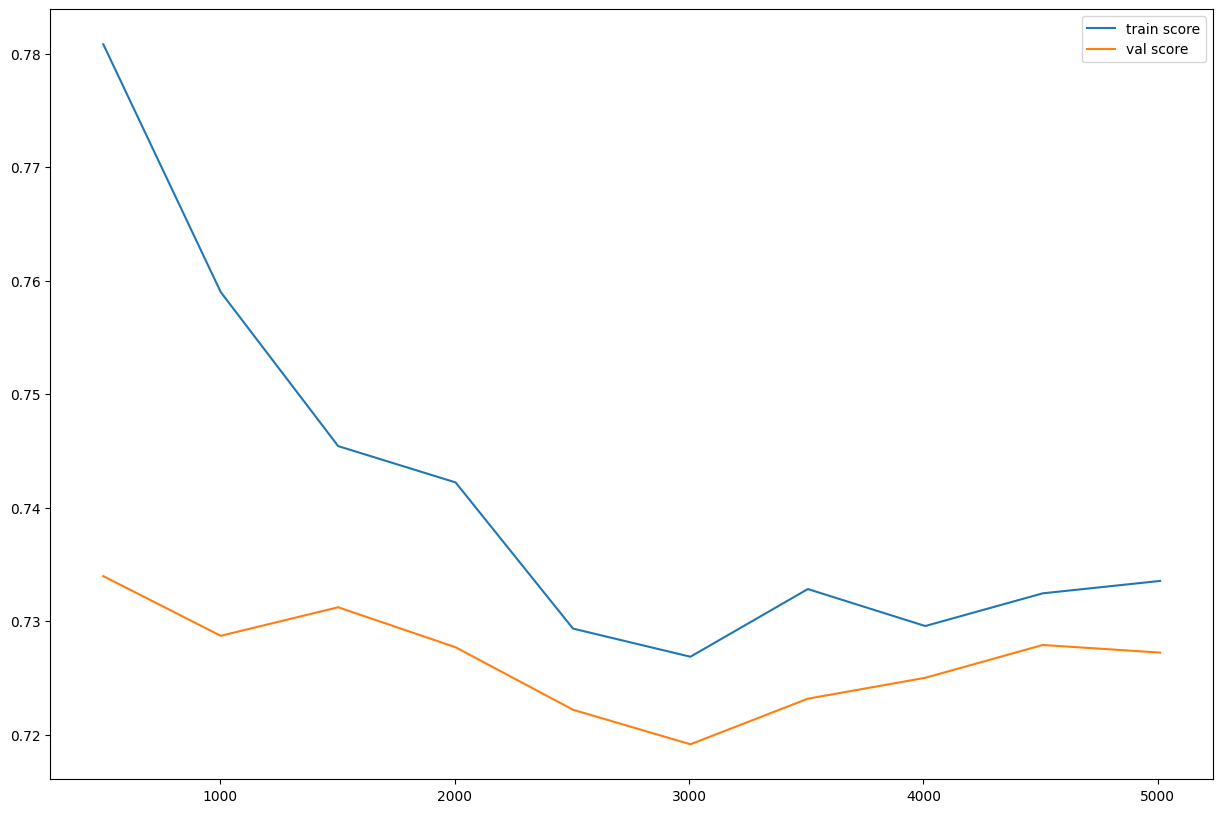

In [73]:
evaluation(SVC_grid.best_estimator_, X_train_2, y_train_2, X_test_2, y_test_2)

In [74]:
SVC_grid.best_estimator_.score(X_test_2, y_test_2)

0.7152740819584885

## Conclusion

Our final scores are very close, 72% accuracy, with a very slight advantage for our LogisticRegression model. This is a relatively good result, since our classes were almost perfectly balanced in our original dataset, and our preprocessed dataset

Good to know that when we have in-game data after 10 minutes, we are able to predict with a 72% accuracy which team is going to win.

Finally, we can take a look at the most important features in these models, which will tell us what features are most important in the first 10mn of a League of Legends game to get the win. This would probably improve a player's winrate over some time and with a significant number of games, if he's able to focus straight away on the most important things.

In [75]:
# listing the params we got from the RandomizedSearch earlier
global_best_params

{'pipeline__selectkbest__k': 67,
 'pipeline__polynomialfeatures__degree': 2,
 'logisticregression__solver': 'liblinear',
 'logisticregression__penalty': 'l2',
 'logisticregression__C': np.float64(7.4)}

We rewrite a simple LogisticRegression just to check our feature importances, since it was pretty difficult and time-consuming to try and get meaningful coefficients after our pipeline and our preprocessing with so many variables added (because of PolynomialFeatures, VarianceThreshold, SelectKBest)

Confusion matrix:
[[669 272]
 [251 687]]

Classification report:
              precision    recall  f1-score   support

           0       0.73      0.71      0.72       941
           1       0.72      0.73      0.72       938

    accuracy                           0.72      1879
   macro avg       0.72      0.72      0.72      1879
weighted avg       0.72      0.72      0.72      1879



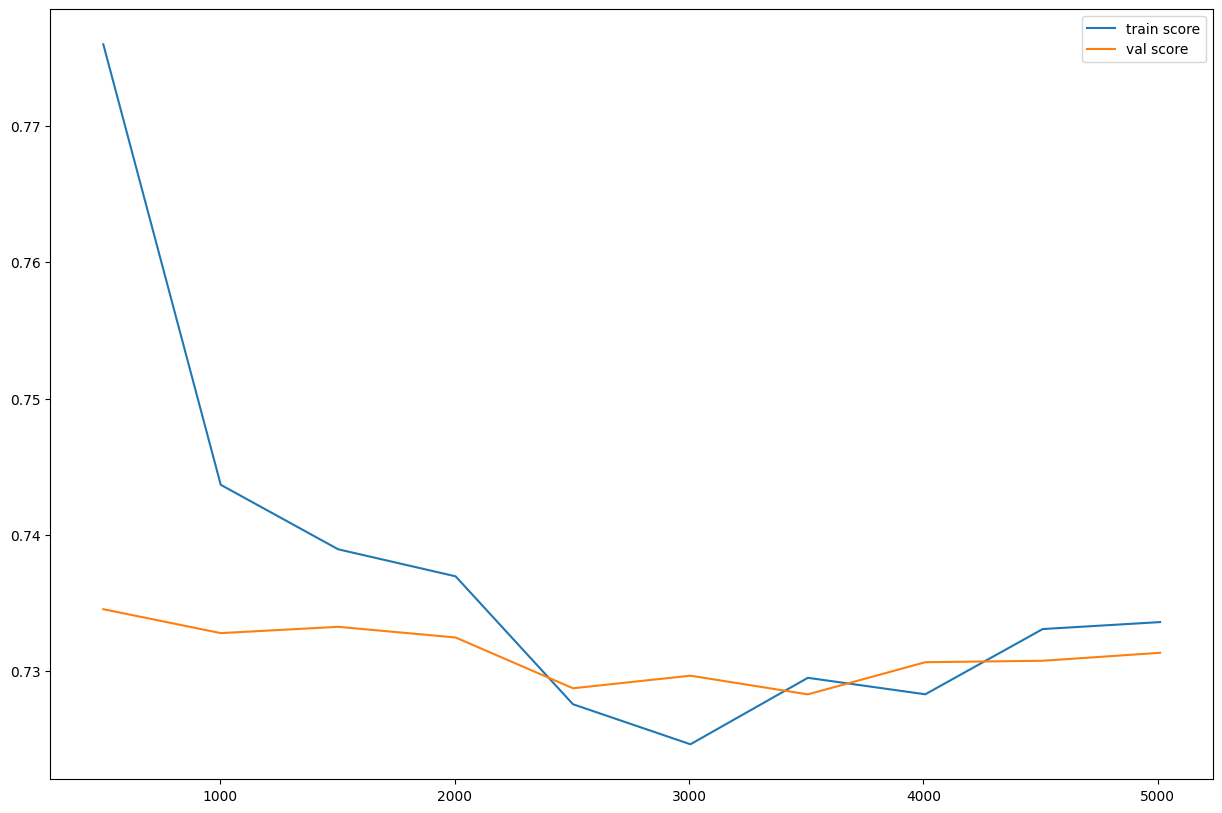

In [76]:
simple_logreg = LogisticRegression(solver='liblinear', penalty='l2', C=7.4, max_iter=500, random_state=42) # picking params from our RandomizedSearch
simple_logreg.fit(X_train_2, y_train_2)

# just making sure this simple model has close results to the one we had after our randomized search
evaluation(simple_logreg, X_train_2, y_train_2, X_test_2, y_test_2)

In [77]:
simple_logreg.score(X_test_2, y_test_2)

0.7216604576902608

Ahaha actually better results for plain accuracy without our preprocessing (almost depressing)

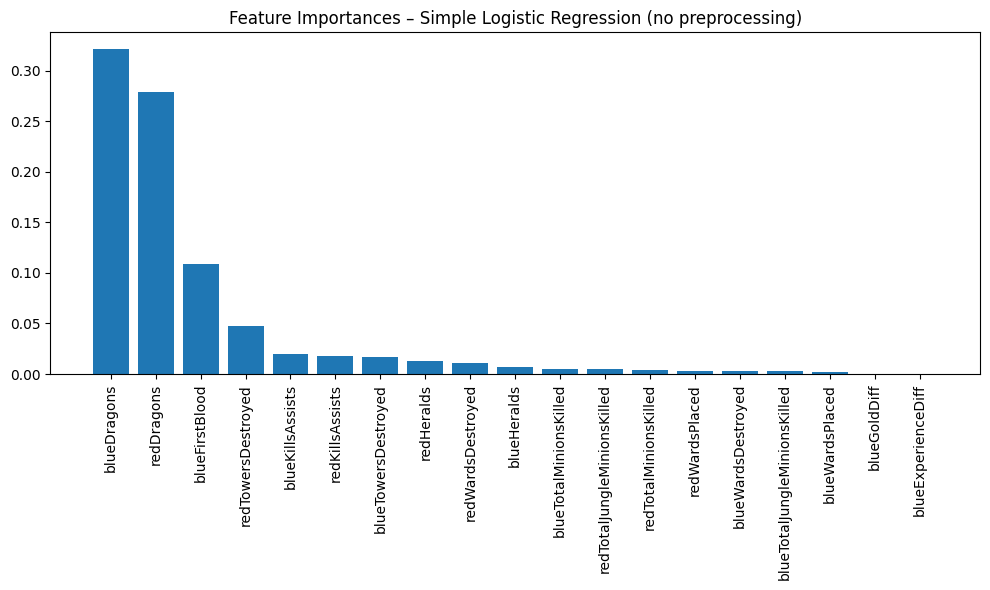

In [78]:
coefs = abs(simple_logreg.coef_[0])

weights = pd.DataFrame({'Feature': X_train_2.columns, 'Importance': coefs}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10,6))
plt.bar(weights['Feature'], weights['Importance'])
plt.xticks(rotation=90)
plt.title('Feature Importances – Simple Logistic Regression (no preprocessing)')
plt.tight_layout()

plt.savefig("images/feature_importance.png", dpi=300)

plt.show();


We can finally see that in our prediction model, Dragons, FirstBlood and redTowersDestroyed are the most important features to decipher who's going to win after the first 10 minutes of the game. 

Since `redTowersDestroyed`is more important than `blueTowersDestroyed`, we can infer than defending your own towers and making sure the enemy team doesn't destroy it is more important than actually destroying a tower yourself